# INFOF422 project report

### Authors: Group 42 - Pacôme Van Overschelde & Bilal Kostet



# 0. Introduction

### 0.1 Project description 

This project was centered around our participation in a coding competition on the website DrivenData, where the goal is to obtain the best prediction method for a dataset of building characteristics collected after the  2015 Gorkha earthquake in Nepal. The value that we aim to predict is the damage grade on the building after this earthquake. 

Through this participation, we are able to apply the learning and validation strategies seen in class and in the practicals to a real\-life problem, and to construct our own strategy to optimize our learning and prediction process. We will implement in this project a data\-preprocessing pipeline funneling our data into a learning model selection procedure, as well as a training procedure not seen in the context of this course. This process will be documented in this notebook, as well as the results obtained.



### 0.3 Problem description

The dataset consists of buildings for which we have several characteristics. Each row of the set corresponds to a different building, identified by the building\_id variable. The target variable that we will want to predict, damage\_grade, is a measure of the damage suffered by the buildings in the 2015 Gorkha earthquake, indicated by an integer going from 1 to 3, corresponding to increasing damage. This target value does not really correspond to an actual measurement, but is more akin to a category. This problem is thus a multiclass classification problem, as we will want to predict the category that a building belongs to, based on the other characteristics.


##### 0.3.1 Relevance of the features and their type

The informations given in the dataset describing the different buildings, and that will allow us to predict the damage_grade are \(taken from the DrivenData problem description\):

- geo\_level\_1\_id, geo\_level\_2\_id, geo\_level\_3\_id \(type: int\): geographic region in which building exists, from largest \(level 1\) to most specific sub\-region \(level 3\). Possible values: level 1: 0\-30, level 2: 0\-1427, level 3: 0\-12567.
- count\_floors\_pre\_eq \(type: int\): number of floors in the building before the earthquake.
- age \(type: int\): age of the building in years.
- area\_percentage \(type: int\): normalized area of the building footprint
- height\_percentage \(type: int\): normalized height of the building footprint.
- land\_surface\_condition \(type: categorical\): surface condition of the land where the building was built. Possible values: n, o, t
- foundation\_type \(type: categorical\): type of foundation used while building. Possible values: h, i, r, u, w.
- roof\_type \(type: categorical\): type of roof used while building. Possible values: n, q, x
- ground\_floor\_type \(type: categorical\): type of the ground floor. Possible values: f, m, v, x, z.
- other\_floor\_type \(type: categorical\): type of constructions used in higher than the ground floors \(except of roof\). Possible values: j, q, s, x.
- position \(type: categorical\): position of the building. Possible values: j, o, s, t.
- plan\_configuration \(type: categorical\): building plan configuration. Possible values: a, c, d, f, m, n, o, q, s, u.
- has\_superstructure\_adobe\_mud \(type: binary\): flag variable that indicates if the superstructure was made of Adobe/Mud.
- has\_superstructure\_mud\_mortar\_stone \(type: binary\): flag variable that indicates if the superstructure was made of Mud Mortar \- Stone.
- has\_superstructure\_stone\_flag \(type: binary\): flag variable that indicates if the superstructure was made of Stone.
- has\_superstructure\_cement\_mortar\_stone \(type: binary\): flag variable that indicates if the superstructure was made of Cement Mortar \- Stone.
- has\_superstructure\_mud\_mortar\_brick \(type: binary\): flag variable that indicates if the superstructure was made of Mud Mortar \- Brick.
- has\_superstructure\_cement\_mortar\_brick \(type: binary\): flag variable that indicates if the superstructure was made of Cement Mortar \- Brick.
- has\_superstructure\_timber \(type: binary\): flag variable that indicates if the superstructure was made of Timber.
- has\_superstructure\_bamboo \(type: binary\): flag variable that indicates if the superstructure was made of Bamboo.
- has\_superstructure\_rc\_non\_engineered \(type: binary\): flag variable that indicates if the superstructure was made of non\-engineered reinforced concrete.
- has\_superstructure\_rc\_engineered \(type: binary\): flag variable that indicates if the superstructure was made of engineered reinforced concrete.
- has\_superstructure\_other \(type: binary\): flag variable that indicates if the superstructure was made of any other material.
- legal\_ownership\_status \(type: categorical\): legal ownership status of the land where building was built. Possible values: a, r, v, w.
- count\_families \(type: int\): number of families that live in the building.
- has\_secondary\_use \(type: binary\): flag variable that indicates if the building was used for any secondary purpose.
- has\_secondary\_use\_agriculture \(type: binary\): flag variable that indicates if the building was used for agricultural purposes.
- has\_secondary\_use\_hotel \(type: binary\): flag variable that indicates if the building was used as a hotel.
- has\_secondary\_use\_rental \(type: binary\): flag variable that indicates if the building was used for rental purposes.
- has\_secondary\_use\_institution \(type: binary\): flag variable that indicates if the building was used as a location of any institution.
- has\_secondary\_use\_school \(type: binary\): flag variable that indicates if the building was used as a school.
- has\_secondary\_use\_industry \(type: binary\): flag variable that indicates if the building was used for industrial purposes.
- has\_secondary\_use\_health\_post \(type: binary\): flag variable that indicates if the building was used as a health post.
- has\_secondary\_use\_gov\_office \(type: binary\): flag variable that indicates if the building was used fas a government office.
- has\_secondary\_use\_use\_police \(type: binary\): flag variable that indicates if the building was used as a police station.
- has\_secondary\_use\_other \(type: binary\): flag variable that indicates if the building was secondarily used for other purposes. 

There are several things we can immediately notice. There are quite a few binary values, that will be encoded as int. There are also a few categorical variables, which means that we will have to use learners that are able to deal with categorical features, or we will have to process them. We can comment on some of them that have obvious characteristics:

**damage\_grade:** This integer is the target variable, a numerical categorical variable. Regression could still work on this kind of value, as this ordinal value holds sense: the bigger the integer, the more damage. This is called ordinal regression.

**building\_id:** This integer is also a numerical categorical variable, a unique identifier of buildings. This numerical value does not hold any real meaning, as it is mentioned that it is random and risks misleading our learning procedures.

**geo\_level\_1,2,3\_id:** These integer variables are also a numerical categorical variable, identifiers of the geographical zone to which the building belongs of different ranges. It is hard to tell if there values hold any real meaning without being able to put them on a map. The increasing numbers could hold some meaning, or it could be some random repartition. In the latter case, this could also be an issue for our algorithms. Treating them as purely categorical variables \(and for example one hot encoding them\) is not feasible for all three of them, as they would create tens of thousands of new features. We will then evaluate afterwards if we need to keep them or not.

**has\_secondary\_use:** This binary variable seems redundant with the other "has\_secondary\_use\_x" variables. 


##### 0.3.2 Performance metric

We will use the micro averaged F1 score to assess the prediction performance of our learning models, which is defined by


$$
P_{micro} = \frac{\sum_{k=1}^3TP_k}{\sum_{k=1}^3TP_k + FP_k} \qquad  R_{micro} = \frac{\sum_{k=1}^3TP_k}{\sum_{k=1}^3TP_k + FN_k}
$$

$$
F_{micro} = \frac{2 P_{micro}R_{micro}}{P_{micro}+R_{micro}}
$$

where $TP_k$ is the amount of true positives for the class k, $FP_k$ is the amount of false positives for the class k, and $FN_k$ is the amount of false negatives for the class k.

##### 0.4 Strategy to implement

This problem is a multiclass classification issue. We will first try to explore the dataset to try to identify any potential obvious issues or transformations to perform. After that, we will try to make the most of the features available to us by engineering them. We will also try to process filter methods that will be fed to our learning models to identify if any variable could be neglected without performance loss. 

The first model that we will try is a linear model, as we want to always start with the most simple model possible to verify if it isn't already enough to solve our problem. While linear models are mostly used for regression, they can be used to solve classification problems by defining exclusion regions, which is the linear discriminant analysis method seen in class.

Decisions trees are particularly adapted to these kind of problems. We will therefore try to train a random forest method on our dataset and evaluate its performance. We will also use eXtreme Gradient Boosting \(xgBoost\) which is a variation of gradient boosted trees as the method for the third section.

As they are quite versatile, we will also try to solve this problem using a neural network. 

Finally, we will try to combine all the predictions obtained from this model into a single ensemble prediction, weighted by the individual performance of each model.



# 1. Pipeline for data preprocessing



We will now implement a pipeline for data preprocessing. 

Since we have chosen 3 different algorithmic families, each with its own specificity, we will end up applying different processing to the data set. 

As a safety measure, when the different pre\-processing steps are finished, the new training set and testing set will be saved on a csv file.


### 1.1 Description of the packages used 



In [21]:
#install.packages('xgboost')
#install.packages('ggplot2')
#install.packages('lattice')
#install.packages('caret')
#install.packages('dplyr')
#install.packages('tictoc')
#install.packages('recipes')
#install.packages('skimr')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Warning message in install.packages("skimr"):
“'lib = "/usr/local/lib/R/site-library"' is not writable”


ERROR: Error in install.packages("skimr"): unable to install packages


In [32]:
library(Matrix) #Used to create sparse matrices for xgboost
library(ggplot2) #Used to create plots
library(lattice) #Used for 
library(caret) #Managing hyperparameter search in 3rd section.
library(dplyr) #Manipulation dataframes made easier
library(tictoc) #Time execution of cells
library(recipes) #Pre-processing of dataframes for certain methods
library(skimr) #Allows to obtain quick summaries of the data and its statistics
library(keras)
library(tensorflow)
library(tidyverse)
library(recipes)
library(randomForest)

Warning message:
"le package 'randomForest' a été compilé avec la version R 4.2.3"
randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


Attachement du package : 'randomForest'


L'objet suivant est masqué depuis 'package:dplyr':

    combine


L'objet suivant est masqué depuis 'package:ggplot2':

    margin




### Import of the data set

Let us first import our dataset into dataframes. We have three files, one containing training values, one containing training labels (the target), and one containing the test values to be tried in DrivenData.

In [39]:
train_values <- read.csv("train_values.csv",stringsAsFactors = T)
test_values <- read.csv("test_values.csv",stringsAsFactors = T)
train_labels <- read.csv("train_labels.csv",stringsAsFactors = T)
submission_format <- read.csv("submission_format.csv",stringsAsFactors = T)

First, we merge the training features with the training labels (targets) in the same dataframe, by using the unique identifier to match the rows.



In [40]:
data <- merge(train_values,train_labels,by=c('building_id','building_id'),all.x=T)
test <- test_values

### 1.2 Data cleaning

Let us have a quick look into our dataset to observe if any obvious issue appears to us.

In [7]:
dim(train_values)
dim(train_labels)
head(train_values,3)
head(train_labels,3)

[1] 260601     39

[1] 260601      2

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,⋯,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,802906,6,487,12198,2,30,6,5,t,r,⋯,0,0,0,0,0,0,0,0,0,0
2,28830,8,900,2812,2,10,8,7,o,r,⋯,0,0,0,0,0,0,0,0,0,0
3,94947,21,363,8973,2,10,5,5,t,r,⋯,0,0,0,0,0,0,0,0,0,0


,building_id,damage_grade
,<int>,<int>
1,802906,3
2,28830,2
3,94947,3


The number of rows seems to be matching, and there is the expected amount of colums. The encoding type of each feature is also the expected one. We can now check for any NAs or missing values.

In [8]:
any(is.na(data))
any(data[,]==" ")
any(data[,]=="")

[1] FALSE

[1] FALSE

[1] FALSE

There is no missing data. We also check if there are any duplicates in the building ids.

In [9]:
any(duplicated(data[,1]))

[1] FALSE

Let us now delve into the dataset to see what are our features and if we could identify any possible issues.

In [10]:
summary(data)

  building_id      geo_level_1_id geo_level_2_id   geo_level_3_id 
 Min.   :      4   Min.   : 0.0   Min.   :   0.0   Min.   :    0  
 1st Qu.: 261190   1st Qu.: 7.0   1st Qu.: 350.0   1st Qu.: 3073  
 Median : 525757   Median :12.0   Median : 702.0   Median : 6270  
 Mean   : 525676   Mean   :13.9   Mean   : 701.1   Mean   : 6258  
 3rd Qu.: 789762   3rd Qu.:21.0   3rd Qu.:1050.0   3rd Qu.: 9412  
 Max.   :1052934   Max.   :30.0   Max.   :1427.0   Max.   :12567  
                                                                  
 count_floors_pre_eq      age         area_percentage   height_percentage
 Min.   :1.00        Min.   :  0.00   Min.   :  1.000   Min.   : 2.000   
 1st Qu.:2.00        1st Qu.: 10.00   1st Qu.:  5.000   1st Qu.: 4.000   
 Median :2.00        Median : 15.00   Median :  7.000   Median : 5.000   
 Mean   :2.13        Mean   : 26.54   Mean   :  8.018   Mean   : 5.434   
 3rd Qu.:2.00        3rd Qu.: 30.00   3rd Qu.:  9.000   3rd Qu.: 6.000   
 Max.   :9.00       

As mentioned previously, the features geo_level_1,2,3_id represent zones of increasing range. We can check if there is any discrepancy in them. Indeed, two buildings in the same geo_level_id_3 should correspond to the same geo_level_id_2, and so on.

In [11]:
mean_level_1 <- data[,2:4] %>% group_by(geo_level_3_id) %>% 
summarize(across(everything(),list(n_distinct)),)
filter(mean_level_1,geo_level_1_id_1 > 1)
filter(mean_level_1,geo_level_2_id_1 > 1)

geo_level_3_id,geo_level_1_id_1,geo_level_2_id_1
<int>,<int>,<int>


geo_level_3_id,geo_level_1_id_1,geo_level_2_id_1
<int>,<int>,<int>


As mentioned while listing the features from the DrivenData summary, has_secondary_use seems redundant with other features. Let us check that.

In [12]:
#We check the indexes of the columns starting with has_secondary_use_
secondary_variables<-which(grepl('has_secondary_use_',colnames(data))) 
check_secondary <- data.frame(matrix(NA,nrow=nrow(data),ncol=1))
for (i in 1:nrow(data)){
    #If has_secondary_use=0, all other has_secondary_use_ columns should be 0
    if (data[i,'has_secondary_use'] == 0) {  
        check_secondary[i,] <- all(data[i,secondary_variables]==0)
    } else {
        #If has_secondary_use=0, at least has_secondary_use_ columns should be 1
        check_secondary[i,] <- any(data[i,secondary_variables]==1) 
    }
    check_secondary[i,]
}
all(check_secondary[,])

[1] TRUE

This feature is thus completely redundant, and we will remove it. We will also remove the building_id column, as it is established that it is a random number, which will thus not be relevant for learning processes.

In [13]:
data <- data[,setdiff(colnames(data),c("building_id","has_secondary_use"))]
test <- test[,setdiff(colnames(test),c("building_id","has_secondary_use"))]

### 1.3 Data visualization, exploration and engineering

The skim function from the package skimr allows us to get a quick and wide view of the dataset.

In [14]:
skimr::skim(data)

── Data Summary ────────────────────────
                           Values
Name                       data  
Number of rows             260601
Number of columns          38    
_______________________          
Column type frequency:           
  factor                   8     
  numeric                  30    
________________________         
Group variables            None  

── Variable type: factor ───────────────────────────────────────────────────────
  skim_variable          n_missing complete_rate ordered n_unique
1 land_surface_condition         0             1 FALSE          3
2 foundation_type                0             1 FALSE          5
3 roof_type                      0             1 FALSE          3
4 ground_floor_type              0             1 FALSE          5
5 other_floor_type               0             1 FALSE          4
6 position                       0             1 FALSE          4
7 plan_configuration             0             1 FALSE         10
8 legal_o

Warning message in is.null(text_repr) || nchar(text_repr) == 0L:
"‘length(x) = 15 > 1’ dans la conversion automatique vers ‘logical(1)’"


,skim_type,skim_variable,n_missing,complete_rate,factor.ordered,factor.n_unique,factor.top_counts,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<lgl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,factor,land_surface_condition,0,1,FALSE,3,"t: 216757, n: 35528, o: 8316",NA,NA,NA,NA,NA,NA,NA,NA
2,factor,foundation_type,0,1,FALSE,5,"r: 219196, w: 15118, u: 14260, i: 10579",NA,NA,NA,NA,NA,NA,NA,NA
3,factor,roof_type,0,1,FALSE,3,"n: 182842, q: 61576, x: 16183",NA,NA,NA,NA,NA,NA,NA,NA
4,factor,ground_floor_type,0,1,FALSE,5,"f: 209619, x: 24877, v: 24593, z: 1004",NA,NA,NA,NA,NA,NA,NA,NA
5,factor,other_floor_type,0,1,FALSE,4,"q: 165282, x: 43448, j: 39843, s: 12028",NA,NA,NA,NA,NA,NA,NA,NA
6,factor,position,0,1,FALSE,4,"s: 202090, t: 42896, j: 13282, o: 2333",NA,NA,NA,NA,NA,NA,NA,NA
7,factor,plan_configuration,0,1,FALSE,10,"d: 250072, q: 5692, u: 3649, s: 346",NA,NA,NA,NA,NA,NA,NA,NA
8,factor,legal_ownership_status,0,1,FALSE,4,"v: 250939, a: 5512, w: 2677, r: 1473",NA,NA,NA,NA,NA,NA,NA,NA
9,numeric,geo_level_1_id,0,1,NA,NA,NA,1.390035e+01,8.033617e+00,0,7,12,21,30,▆▇▅▅▅


Let us comment some interesting points we can notice in the dataset.
* There are 40 columns. Removing the target, it amounts to 39 features to be considered.
* 8 of these features are categorical, while the rest is numerical. Among those numerical features, most of them are binary values. Some other are actually numerical categories: the histograms of building_id, geo_level_1,2,3_id confirms this.
* Most of the binary features are almost entirely imbalaced towards zero, except "has_superstructure_mud_mortar_brick". This also means that our data is sparse. 
* Our target value, damage_grade, seems to be imbalanced.
* There is a huge gap between the latest quartile and the maximum value for the features age, height_percentage, and area_percentage. This is indicative of outliers.

Let us look a bit more into the histograms of the geo_level_1,2,3_ids. 

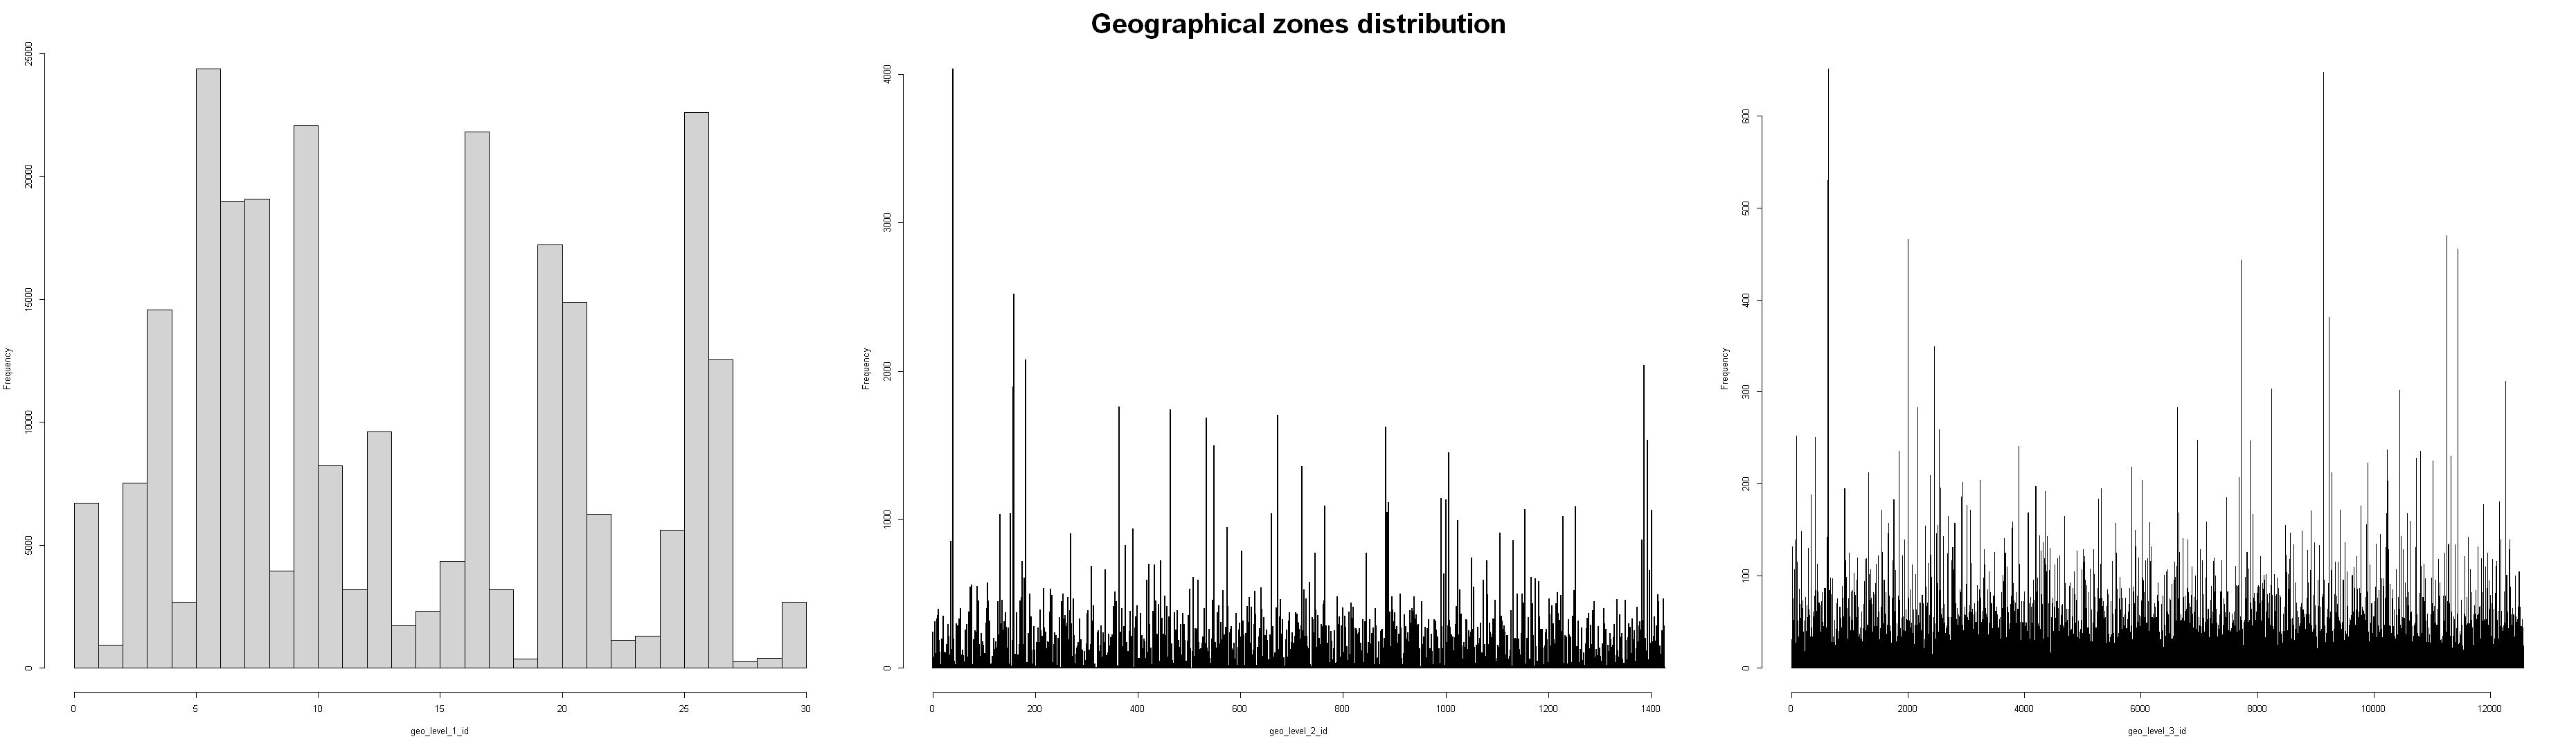

In [15]:
options(repr.plot.width=31, repr.plot.height=9)
par(mfrow=c(1,3)) 
hist(data$geo_level_1_id,xlab='geo_level_1_id',main='',breaks=30)
hist(data$geo_level_2_id,xlab='geo_level_2_id',main='Geographical zones distribution',cex.main=3,breaks=1427)
hist(data$geo_level_3_id,xlab='geo_level_3_id',main='',breaks=12567)

We can notice that some zones are extremely more represented than others, and some others do not have a lot of buildings. 
Let us plot the histogram distribution of damage_grade for all buildings.

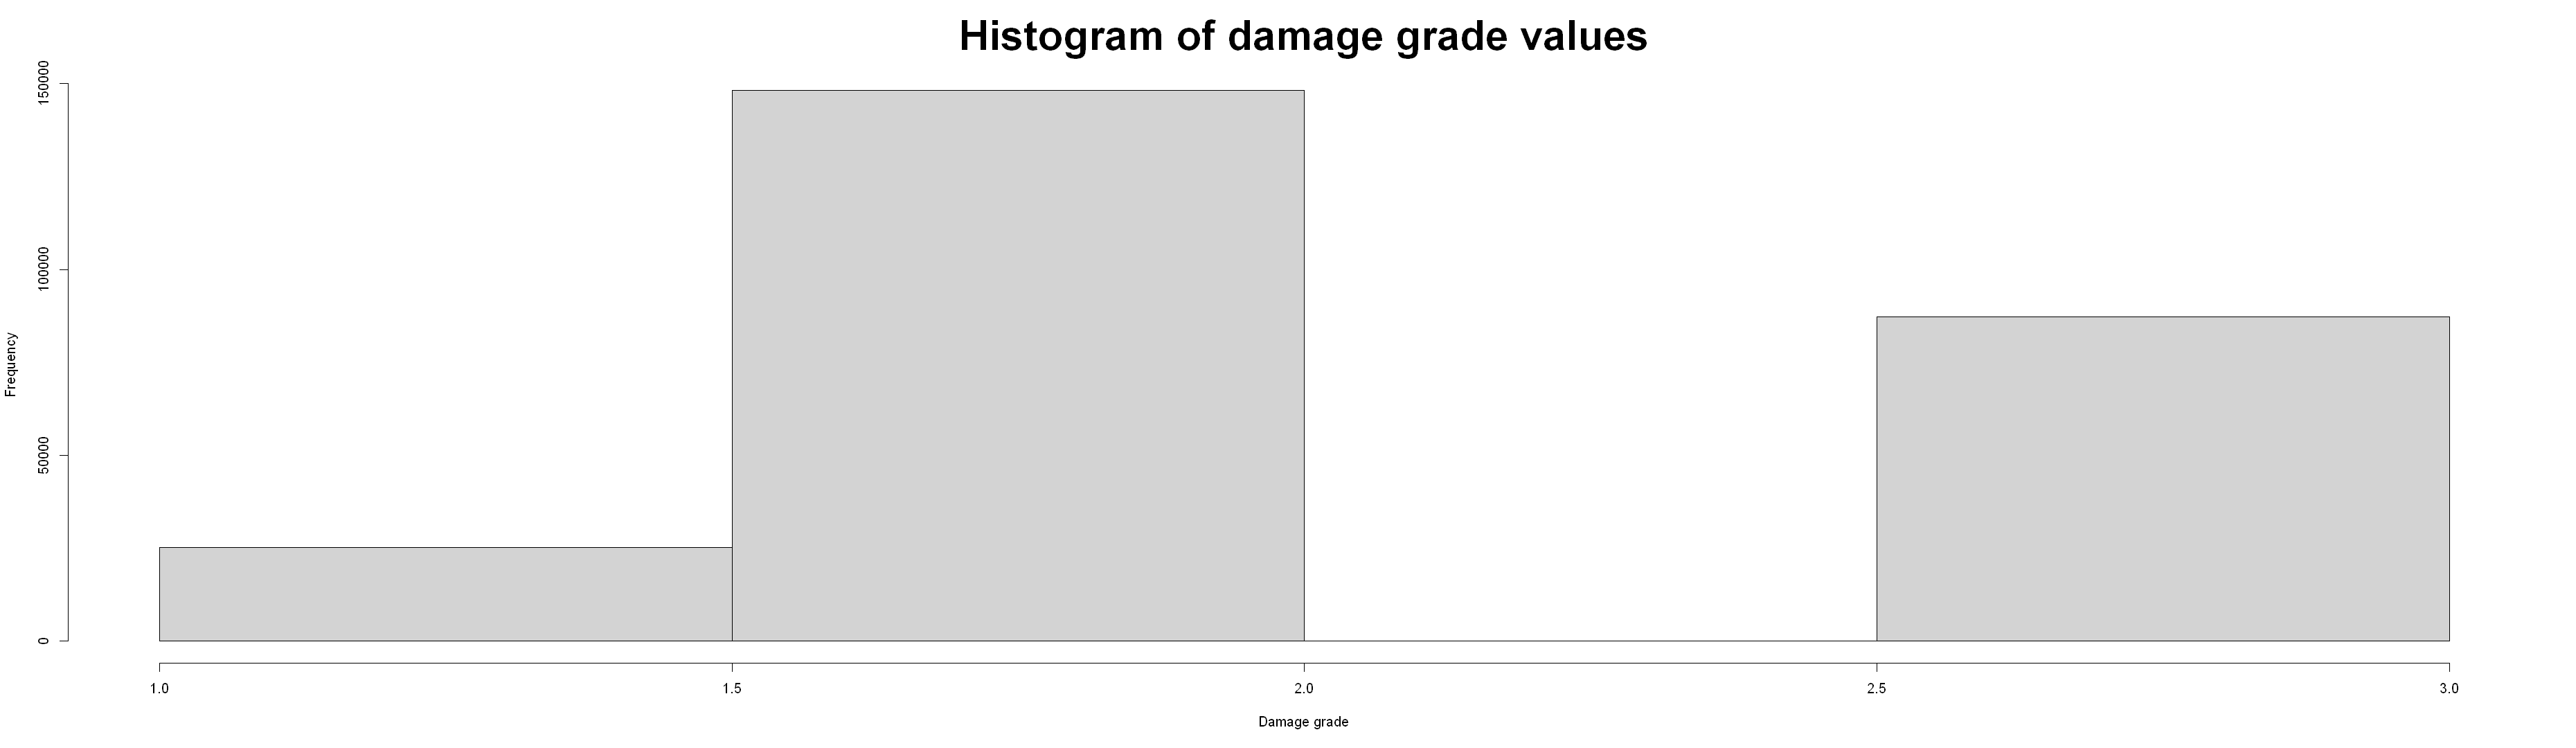

In [16]:
hist(data$damage_grade,xlab='Damage grade',main='Histogram of damage grade values',cex.main=3,breaks=3)

This confirms that the target values are extremely unbalanced. This can be an issue for some classification methods. For this reason, we will try later two strategies to counterbalance this: undersampling and oversamping. 
In the first case, we will equilibrate the distributions by resampling the two majority classes to the same number of lines than the less represented class.
In the second case, we will resample with replacement the two lowest classes to the same number of lines as the most represented class.

We check now for the possible outliers. These outliers may be an issue when we decide to normalize our values, which is necessary when dealing with neural networks.



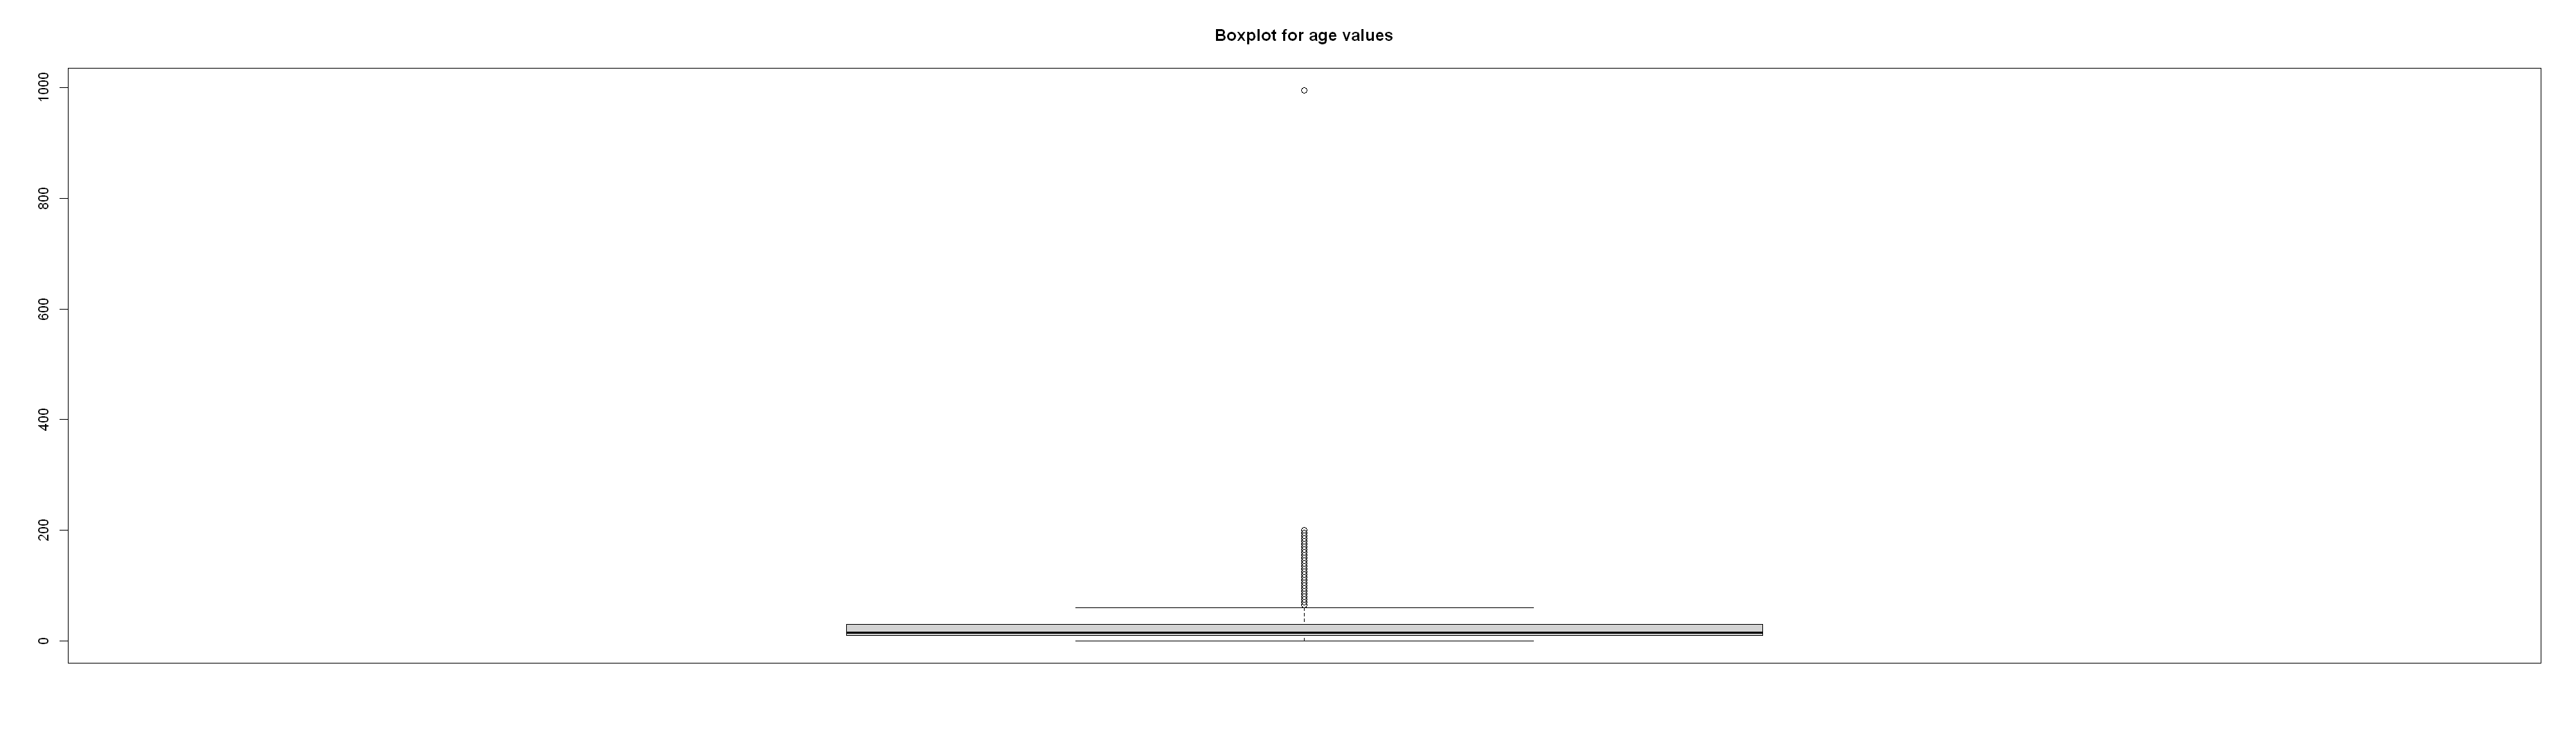

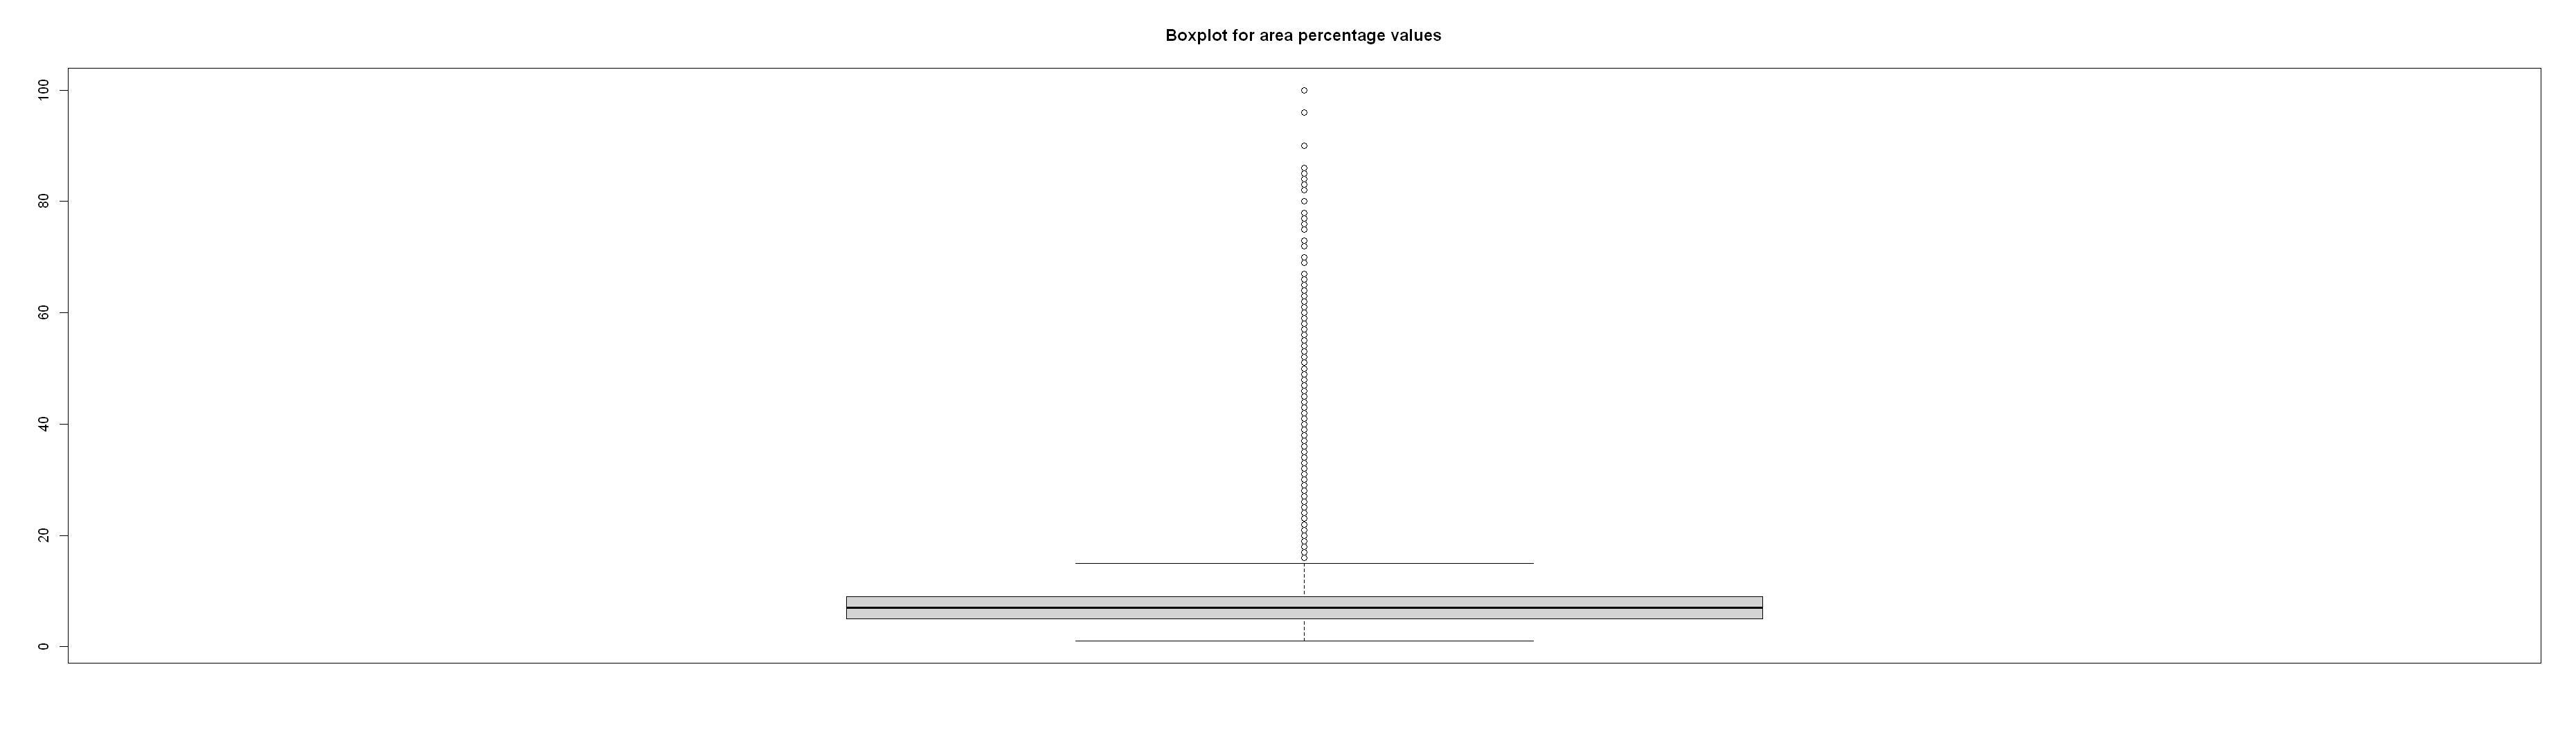

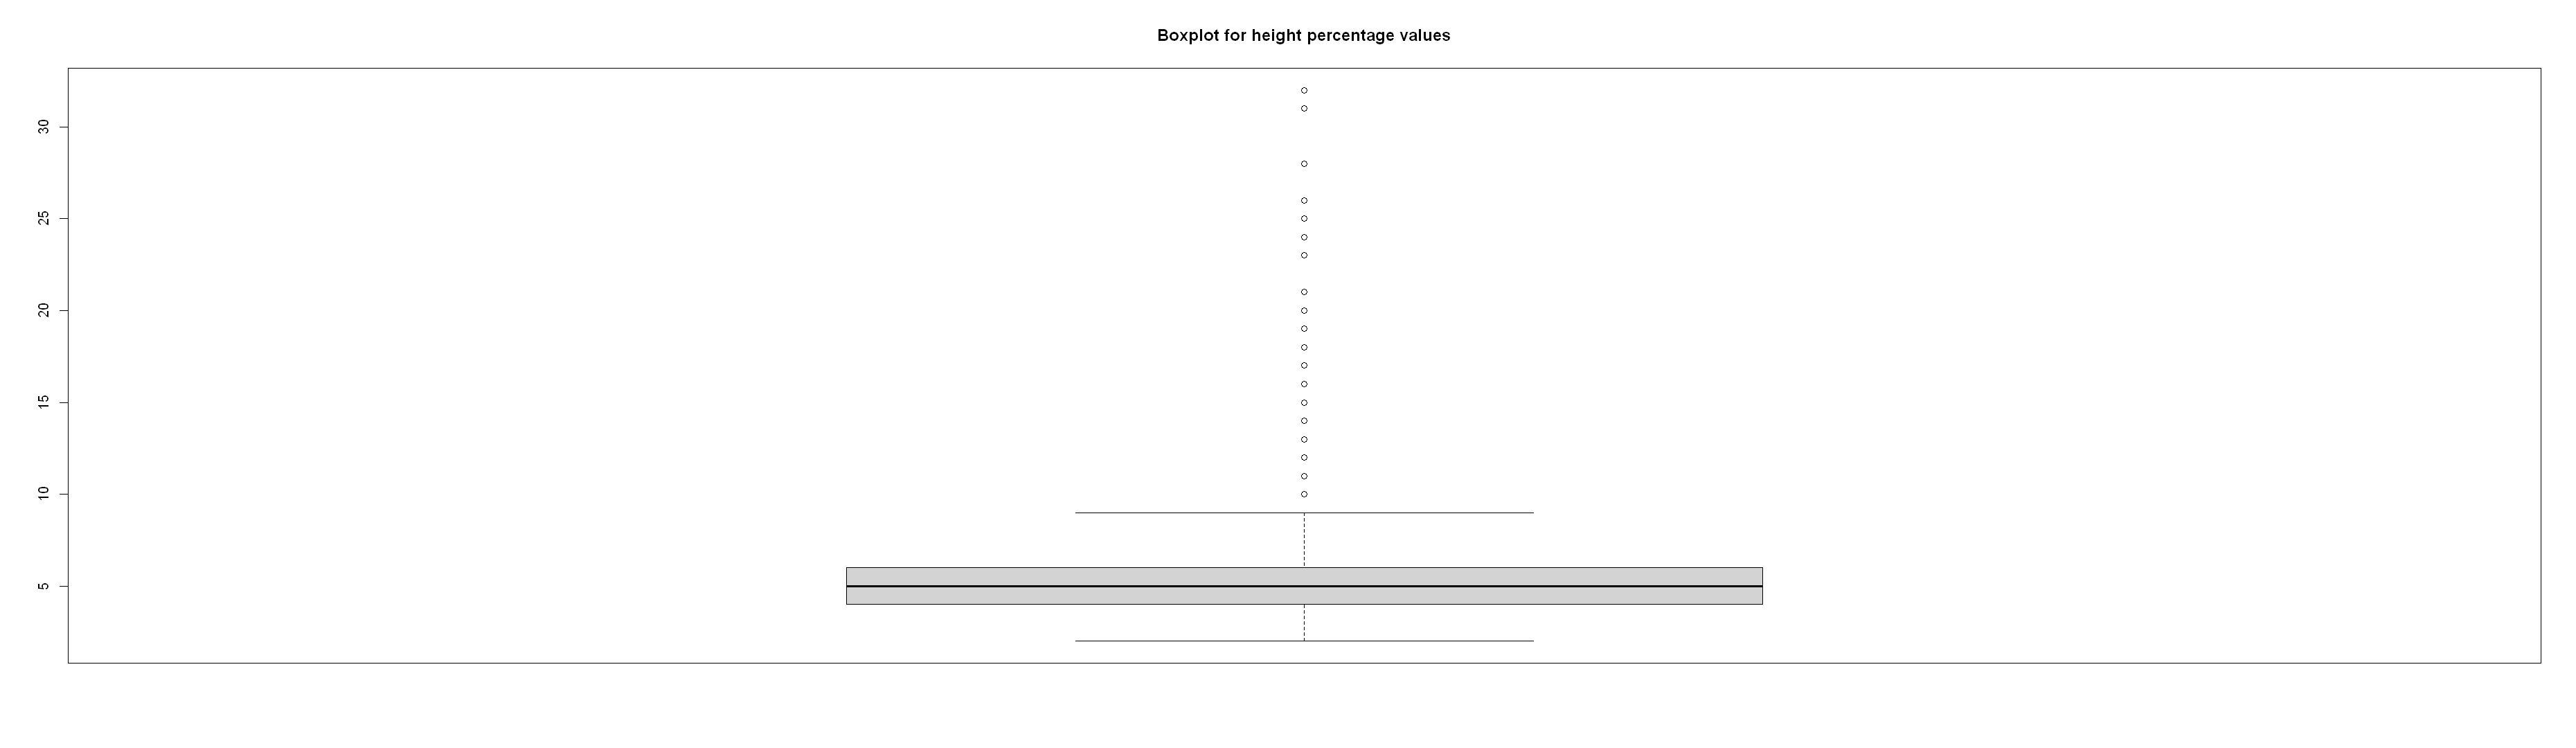

In [17]:
boxplot(data$age,main='Boxplot for age values')
boxplot(data$area_percentage,main='Boxplot for area percentage values')
boxplot(data$height_percentage,main='Boxplot for height percentage values')

There are outliers in all three features. However, the age outliers are clearly worse than for the two other variables. Additionnally, the extreme outlier value of ~1000 years seems very peculiar, while the outliers seem coherent  
 for the two others. 


In [18]:
head(filter(data[,],age > 900 & area_percentage <= 1000))

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2,708,2071,1,995,11,3,t,i,x,⋯,0,1,0,0,0,0,0,0,0,2
2,8,1403,2038,2,995,6,6,n,r,n,⋯,0,0,0,0,0,0,0,0,0,3
3,26,1132,9472,2,995,8,5,t,r,q,⋯,0,0,0,0,0,0,0,0,0,3
4,6,314,12526,2,995,6,7,t,r,n,⋯,0,0,0,0,0,0,0,0,0,2
5,17,957,8213,3,995,14,7,t,r,n,⋯,0,0,0,0,0,0,0,0,0,3
6,24,628,11511,2,995,8,5,n,r,n,⋯,0,0,0,0,0,0,0,0,0,2


This value of 995 is clearly either an encoding mistake, or some placeholder for building whose real age is not known. We therefore choose to remove it, creating a new dataframe that will be used for methods that require normalization, such as neural networks. A last argument for removing these outliers is that if we filter our dataset on these lines, we see that they follow \(very closely!\) the same damage\_grade distribution as the whole dataset: it is then likely that they do not add significant information.  
 


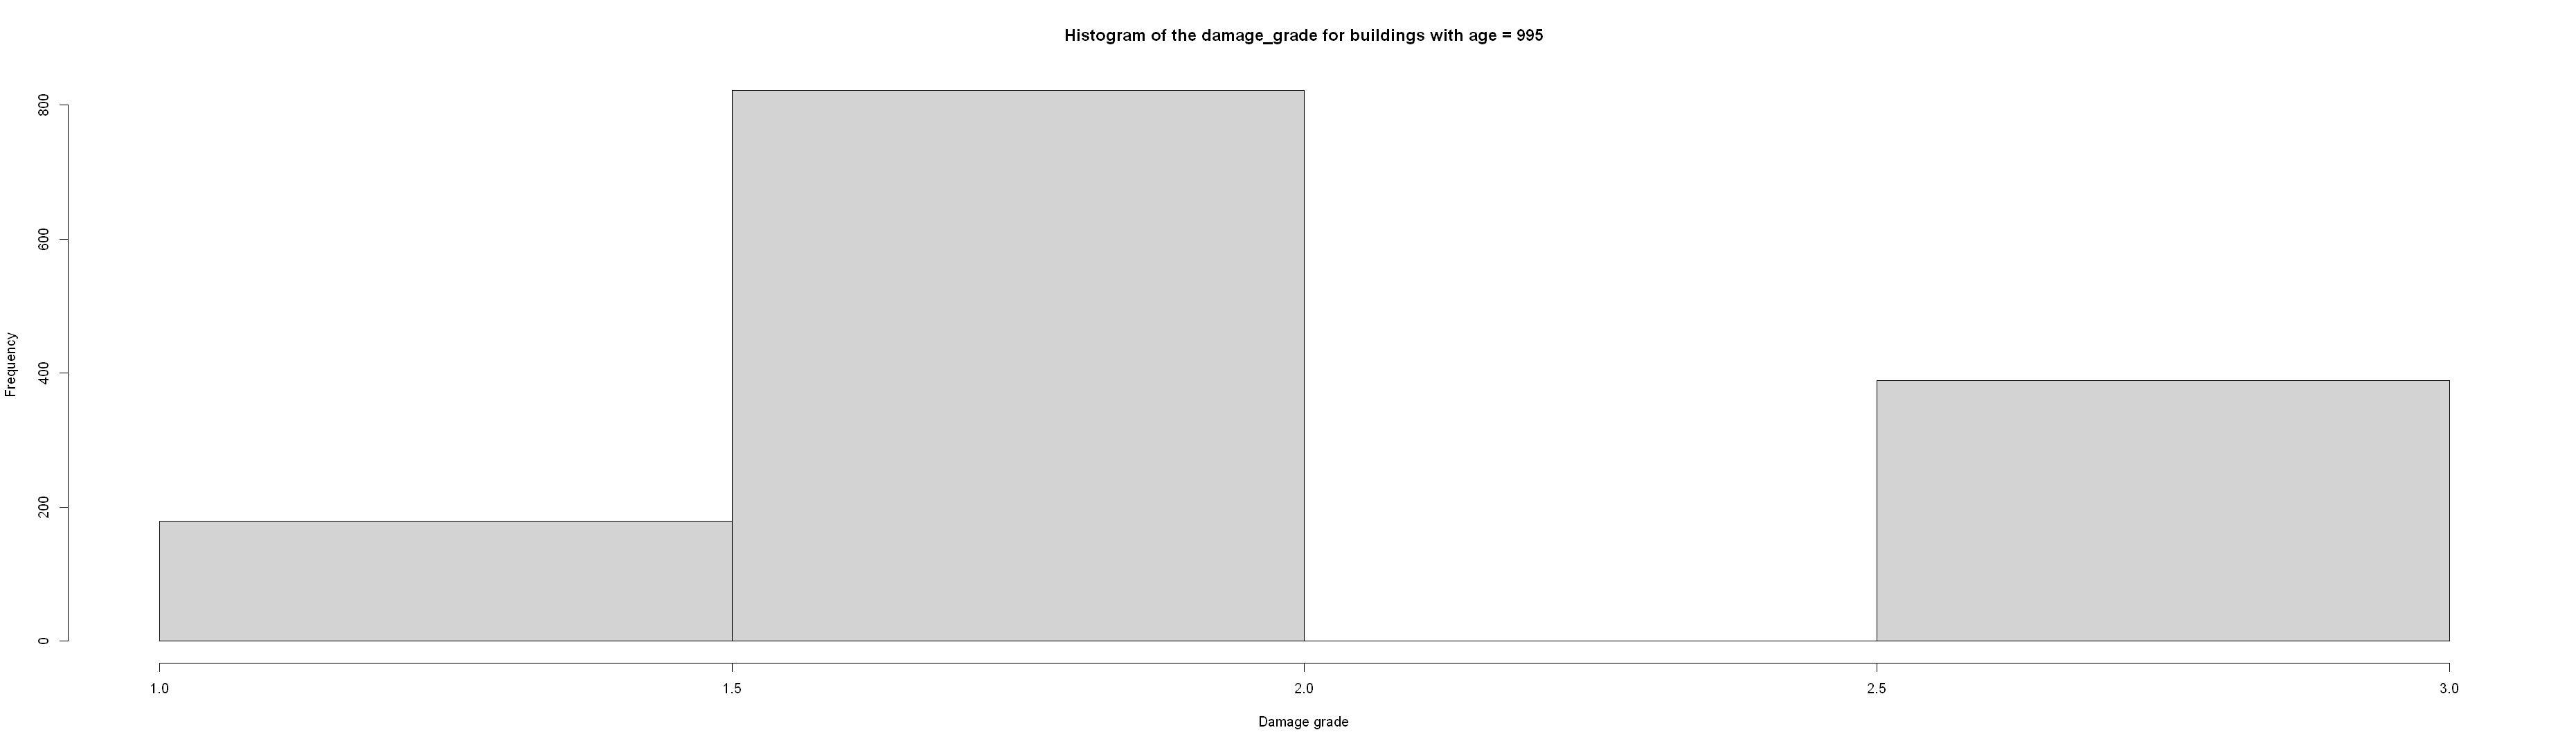

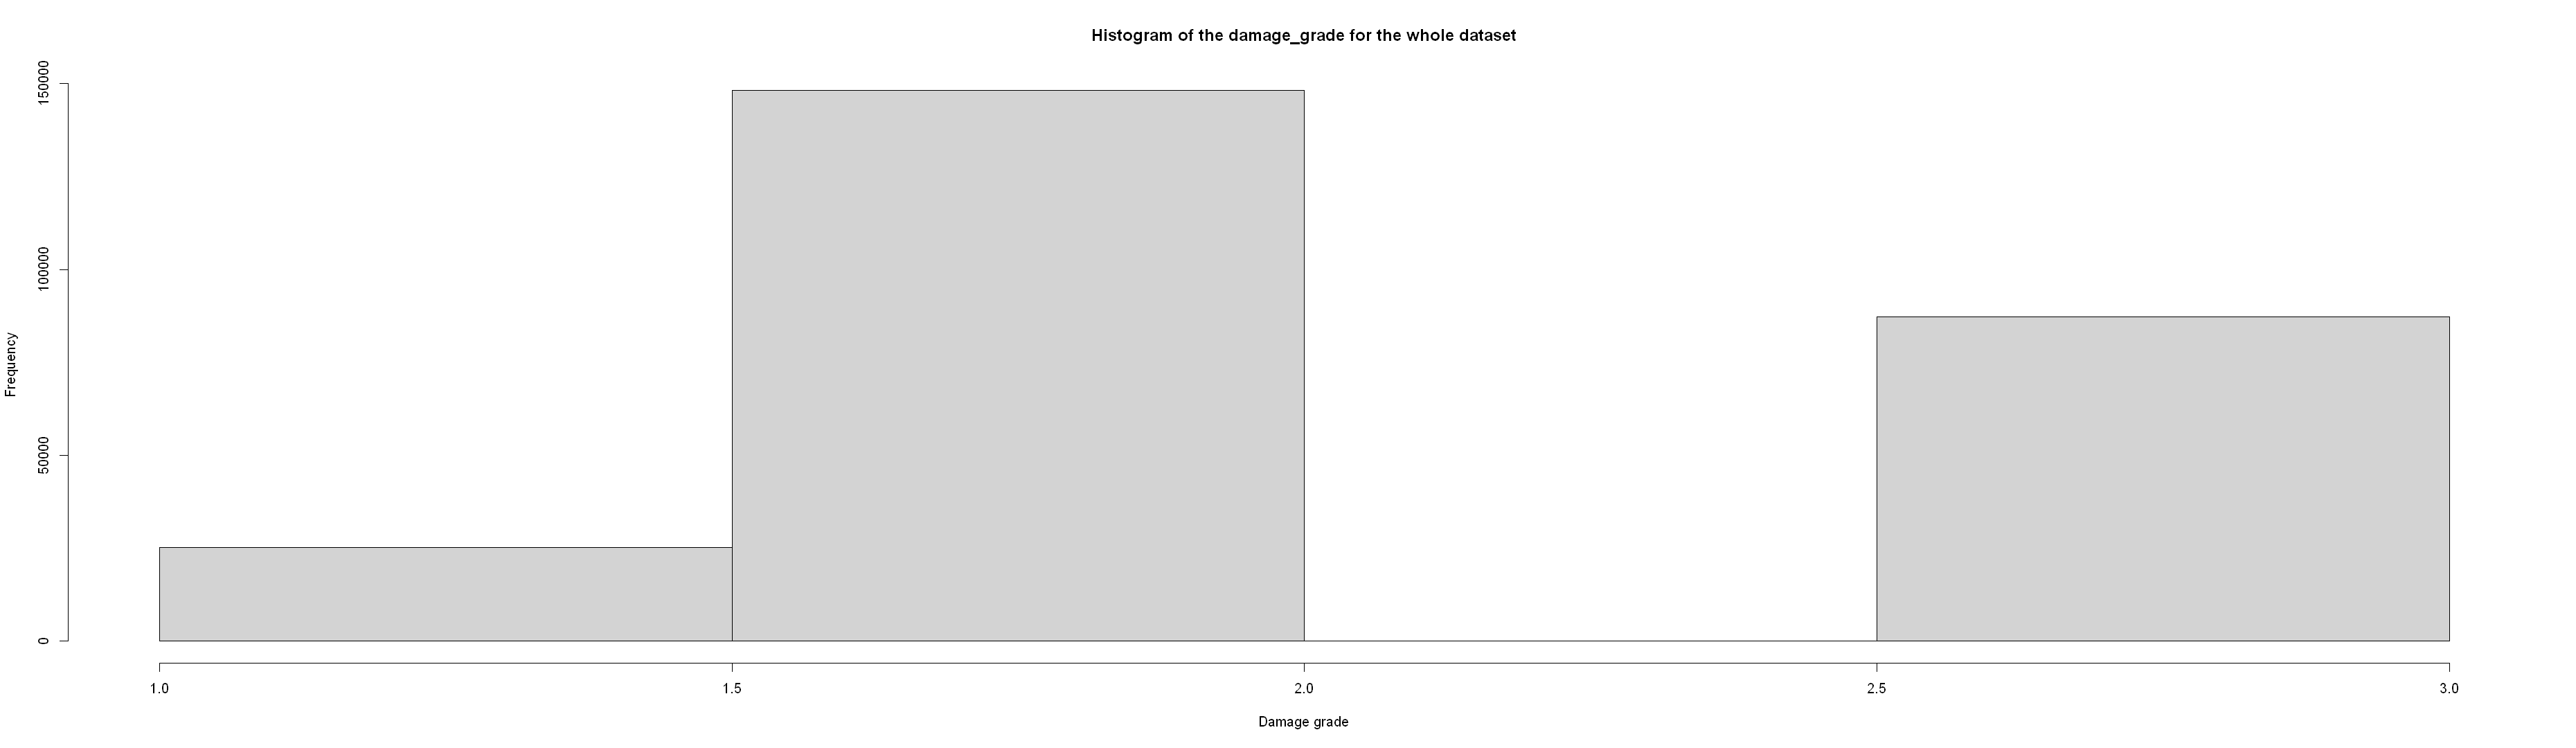

In [19]:
hist(filter(data[,],age==995)$damage_grade,main='Histogram of the damage_grade for buildings with age = 995',xlab='Damage grade',breaks=3)
hist(data$damage_grade, main='Histogram of the damage_grade for the whole dataset',xlab='Damage grade',breaks=3)

In [20]:
dataNN<-filter(data,age<995)

#### Target encoding

For each zone possible in geo_level_1_id, we will calculate the average and standard deviation of the damage_grade for all buildings in this zone. We will proceed to do the same for the zones in geo_level_2 and geo_level_3, and we store this information in a vector of size equal to the number of different zones for each geo_level.
If one of the geo_level fields does not appear in the training set, we will store the NA value instead.

After coming up with the idea of computing the average of each zone to obtain a feature with more sense that the geo\_level ids, we discovered that this process was actually called target encoding, and that we could also compute the standard deviations to obtain even more information. However, we must be careful as this process risks inducing overfitting in our models. We will be careful to check if there is overfitting in our models in the future.  



In [21]:
# We create a mean_damage_level vector of the size of the number of different zones in each geo_level in which we will store the mean_grade of the corresponding zone.
mean_damage_level_1 <- 0:30
mean_damage_level_2 <- 0:1427
mean_damage_level_3 <- 0:12567

# Same thing for the standard deviation.
sd_damage_level_1 <- 0:30
sd_damage_level_2 <- 0:1427
sd_damage_level_3 <- 0:12567

# We use 'dplyr' to calculate the average damage_grade on each zone via a groupdy.
mean_level_1 <- data %>% group_by(geo_level_1_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

mean_level_2 <- data %>% group_by(geo_level_2_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

mean_level_3 <- data %>% group_by(geo_level_3_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

# Same thing for the standard deviation.
sd_level_1 <- data %>% group_by(geo_level_1_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

sd_level_2 <- data %>% group_by(geo_level_2_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

sd_level_3 <- data %>% group_by(geo_level_3_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

# We have previously seen that all fields of geo_level_1 appear in the training dataset, so we do not have to worry about missing values. 
for (i in 1:31){mean_damage_level_1[i] <- mean_level_1[i,2]}  


# Since some areas of geo_level_2 are missing in the training set, we encode a NA instead.
# The k index ensures that only zones that exist in the dataset are considered. If a zone index (i) does not exist in the dictionary mean_level_2, it is encoded as NA, and we do not skip to the next dictionary line. We will use this later as a condition for encoding the mean of the larger zone. 

k <- 1
for (i in 1:1428){if(i-1 == mean_level_2[k,1]){     # The zones start at zero, so we take the index i-1
        mean_damage_level_2[i] <- mean_level_2[k,2]
        k <- k+1 } else { mean_damage_level_2[i] <- NA}}

k <- 1
for (i in 1:12568){if(i-1 == mean_level_3[k,1]){ 
        mean_damage_level_3[i] <- mean_level_3[k,2]
        k <- k+1 } else { mean_damage_level_3[i] <- NA}}


# Same thing for the standard deviation.
for (i in 1:31){sd_damage_level_1[i] <- sd_level_1[i,2]}  

k <- 1
for (i in 1:1428){if(i-1 == sd_level_2[k,1]){ 
        sd_damage_level_2[i] <- sd_level_2[k,2]
        k <- k+1 } else { sd_damage_level_2[i] <- NA}}

k <- 1
for (i in 1:12568){if(i-1 == sd_level_3[k,1]){ 
        sd_damage_level_3[i] <- sd_level_3[k,2]
        k <- k+1 } else { sd_damage_level_3[i] <- NA}}

With the previously created sd\_damage\_level and mean\_damage\_level vectors, we will add this information to the dataset. 
We are careful not to add a NA value in the data set, instead we add the damage\_level of the larger area if it is not included in the training set. Since we saw earlier that all the fields in geo\_level\_1 appear in the training dataset, we are assured that in the worst case, mean\_damge\_level\_1 is encoded for mean\_damage\_level\_2 and mean\_damage\_level\_3.

We create a function that will process both train and test sets in the same way.


In [22]:
# We now encode for each line of the dataset the newly created features.
for (i in 1:nrow(data)){
    if(is.na(mean_damage_level_3[data[i,c("geo_level_3_id")]+1])){
        if(is.na(mean_damage_level_2[data[i,c("geo_level_2_id")]+1])){
            data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
        } else {data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
    } else {data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_3[data[i,c("geo_level_3_id")]+1]))
            data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
            data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
}

for (i in 1:nrow(data)){
    if(is.na(sd_damage_level_3[data[i,c("geo_level_3_id")]+1])){
        if(is.na(sd_damage_level_2[data[i,c("geo_level_2_id")]+1])){
            data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
        } else {data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
    } else {data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_3[data[i,c("geo_level_3_id")]+1]))
            data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
            data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
}

We handle the test sets in the same way.



In [ ]:
for (i in 1:nrow(test)){
    if(is.na(mean_damage_level_3[test[i,c("geo_level_3_id")]+1])){
        if(is.na(mean_damage_level_2[test[i,c("geo_level_2_id")]+1])){
            test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
        } else {test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
    } else {test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_3[test[i,c("geo_level_3_id")]+1]))
            test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
            test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
}

for (i in 1:nrow(test)){
    if(is.na(sd_damage_level_3[test[i,c("geo_level_3_id")]+1])){
        if(is.na(sd_damage_level_2[test[i,c("geo_level_2_id")]+1])){
            test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
        } else {test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
    } else {test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_3[test[i,c("geo_level_3_id")]+1]))
            test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
            test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
}

It is more convenient to keep the damage\_grade column at the end, especially in the feature selection part to apply methods such as mRMR.


In [24]:
data <- data %>% relocate(geo_level_1_mean_damage,.after=geo_level_1_id) %>% 
relocate(geo_level_2_mean_damage,.after=geo_level_2_id) %>% 
relocate(geo_level_3_mean_damage,.after=geo_level_3_id) %>% 
relocate(geo_level_1_sd_damage,.after=geo_level_1_mean_damage) %>%
relocate(geo_level_2_sd_damage,.after=geo_level_2_mean_damage) %>% 
relocate(geo_level_3_sd_damage,.after=geo_level_3_mean_damage)

test <- test %>% relocate(geo_level_1_mean_damage,.after=geo_level_1_id) %>% 
relocate(geo_level_2_mean_damage,.after=geo_level_2_id) %>% 
relocate(geo_level_3_mean_damage,.after=geo_level_3_id) %>% 
relocate(geo_level_1_sd_damage,.after=geo_level_1_mean_damage) %>%
relocate(geo_level_2_sd_damage,.after=geo_level_2_mean_damage) %>% 
relocate(geo_level_3_sd_damage,.after=geo_level_3_mean_damage)

ERROR: Error in UseMethod("relocate"): pas de méthode pour 'relocate' applicable pour un objet de classe "NULL"


As explained earlier, in this form, the geo_level id features may have very little sense as an integer value.
It could have a meaning that we don't understand, but in this instance, we have compared the performance of the models that will be presented later in both cases, and keeping them did not seem to significantly improve the performance of the algorithm. We thus decided to remove them.

In [ ]:
data <- data[,setdiff(colnames(data),c("geo_level_1_id","geo_level_2_id","geo_level_3_id"))]
test <- test[,setdiff(colnames(test),c("geo_level_1_id","geo_level_2_id","geo_level_3_id"))]

In [ ]:
#write.csv(data, file = "data_target_encoding.csv", row.names = FALSE)
#write.csv(test, file = "test_target_encoding.csv", row.names = FALSE)

#### One\-hot encoding and standardisation



Some methods cannot handle categorical features, and only work with numerical values. For this reason, we will one hot encode those feature, meaning that each of the unique possible value of these categorical features will become a new binary feature. We will use the recipes package to easily normalize our data, as well as one-hot encode them (including the damage_grade). 

In [ ]:
dataNN <- recipe(damage_grade ~ ., data) %>%
  step_normalize(count_floors_pre_eq, age, area_percentage, height_percentage, geo_level_1_mean_damage, geo_level_2_mean_damage, geo_level_3_mean_damage, geo_level_1_sd_damage,geo_level_2_sd_damage,geo_level_3_sd_damage) %>%
  step_num2factor('damage_grade',levels=c('1','2','3')) %>%
  step_dummy(all_nominal(), one_hot = TRUE) %>%
  prep(log_changes=TRUE) %>%
  bake(new_data = NULL)

testNN <- recipe(~ ., test) %>%
  step_normalize(count_floors_pre_eq, age, area_percentage, height_percentage, geo_level_1_mean_damage, geo_level_2_mean_damage, geo_level_3_mean_damage, geo_level_1_sd_damage,geo_level_2_sd_damage,geo_level_3_sd_damage) %>%
  step_dummy(all_nominal(), one_hot = TRUE) %>%
  prep(log_changes=TRUE) %>%
  bake(new_data = NULL)

step_normalize (normalize_Ph2Qf): same number of columns

step_num2factor (num2factor_j1aVj): same number of columns

step_dummy (dummy_9vPbg): 
 new (41): land_surface_condition_n, land_surface_condition_o, ...
 removed (9): land_surface_condition, foundation_type, roof_type, ...

step_normalize (normalize_xArmD): same number of columns

step_dummy (dummy_QLpM9): 
 new (38): land_surface_condition_n, land_surface_condition_o, ...
 removed (8): land_surface_condition, foundation_type, roof_type, ...



In [ ]:
#write.csv(dataNN, file = "data_target_encoding_NN.csv", row.names = FALSE)
#write.csv(testNN, file = "test_target_encoding_NN.csv", row.names = FALSE)

With our data now one hot encoded, it is possible to compute the correlation matrix of our dataset. 

In [ ]:
data_cor=cor(data)
dim(data_cor)
ggcorr(data,cor_matrix=data_cor,angle=-45)

In [ ]:
which(abs(data_cor-diag(rep(1,nrow(data_cor))))>0.8,arr.ind=TRUE)

Most variables are very lowly correlated as we can see from this correlation map. Only 6 features are higly correlated. High correlation could be indicative of multicollinearity, which is a big issue for linear models. Other models can also be affected by correlated features. In this case, since there are so few features affected, we decide to not pursue this lead, and will rather use a more balanced strategy: mRMR.

Another possible source of multicollinearity in this case is the one hot encoding process. Indeed, it is sometimes best to avoid to encode all of the unique different possible values of our categories while one hot encoding them. It is actually necessary to remove one of them, as it will be necessarily entirely correlated with all the other features created, leading to multicollinearity. This could be an issue for linear models, so we will remove them in a new dataframe specifically dedicated to this model.

In [ ]:
#We check here the indices of all 8 different one hot encoded features to delete them later.
dataNN[1:3,c(34,37,42,45,50,54,58,68)]

In [ ]:
dataNN.lin <- dataNN[,-c(34,37,42,45,50,54,58,68)]
testNN.lin <- testNN[,-c(34,37,42,45,50,54,58,68)]

We will also make sure that there is no feature with a zero or near zero variance. This could be a problem as it will make the matrix $(X_{train})^tX_{train}$ non invertible. We will use the function nearZeroVar from the caret package.

In [ ]:
# nearZeroVar indicates which variables have near zero variance. We avoid including the target in this process.
nzv <- nearZeroVar(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
dataNN.lin <- dataNN.lin[, -nzv] # We remove the near zero variance variables
testNN.lin <- testNN.lin[, -nzv]

### 1.4 Feature selection

We decided to perform the feature selection using mRMR in addition to the embedded method specific to each algorithm. 

Since we have to deal with a lot of binary and categorical variables, feature selection with PCA did not seem to be a suitable procedure for our problem. 

In order to identify which features of the data we should keep in priority, we will use two strategies.

First, we will compute a feature importance list through the Maximum Relevance — Minimum Redundancy \(mRMR\) seen in class. This allows to rank features by balancing how correlated they are with the target \(a good thing\) with how correlated they are amongst each other \(a bad thing\). Since values have to be numerical to be able to compute the correlations needed for this method, we will only use it on the dataset that went through one hot encoding that we will use for neural networks.

Second, the other dataset will be used with decision tree based methods. This is convenient, since these methods have embedded feature selection processes. Since it selects the feature on which the three will be split at each decision node by checking the maximum of the information gain for all the features, this method allows to return a ranking of the most used features in the splitting processes. This is what we will rather use in this case.


Let us perform the mRMR ranking for the one hot encoded dataset.

In [ ]:
set.seed(2)
targets<-which(grepl('damage_grade',colnames(dataNN)))
n<-ncol(dataNN)
correlation<-abs(cor(dataNN[,-targets,drop=F],dataNN[,targets,drop=F]))
selected<-c()
candidates<-1:(n-length(targets))

#mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
for (j in 1:n) {
    redundancy_score<-numeric(length(candidates))

    if (length(selected)>0) {
        # Compute the correlation between the selected variables and the candidates on the training set
        cor_selected_candidates<-abs(cor(dataNN[,selected,drop=F],dataNN[,candidates,drop=F]))
        # Compute the mean correlation for each candidate variable, across the selected variables
        redundancy_score<-apply(cor_selected_candidates,2,mean)
    }

    # mRMR: minimum Redundancy Maximum Relevancy
    mRMR_score<-correlation[candidates]-redundancy_score

    # Select the candidate variable that maximises the mRMR score
    selected_current<-candidates[which.max(mRMR_score)]
    selected<-c(selected,selected_current)

    # Remove the selected variables from the candidates
    candidates<-setdiff(candidates,selected_current)
}

rankingNN <- selected

In [ ]:
rankingNN
colnames(dataNN)[rankingNN]

[1]  5 37  8 12  6  3 50 20 38 22 46  1  4 43 49 19 40 16 25 21 44 67 51  2 13
[26] 23 59  7 35 41 24 11 36 39 26  9 57 28 69 30 63 27 29 58 66 15 48 60 45 42
[51] 32 31 14 62 33 65 61 56 34 68 70 18 64 47 52 54 17 53 10 55

[1] "geo_level_3_mean_damage"               
 [2] "foundation_type_i"                     
 [3] "age"                                   
 [4] "has_superstructure_mud_mortar_stone"   
 [5] "geo_level_3_sd_damage"                 
 [6] "geo_level_2_mean_damage"               
 [7] "other_floor_type_q"                    
 [8] "has_superstructure_rc_engineered"      
 [9] "foundation_type_r"                     
[10] "count_families"                        
[11] "ground_floor_type_v"                   
[12] "geo_level_1_mean_damage"               
[13] "geo_level_2_sd_damage"                 
[14] "roof_type_x"                           
[15] "other_floor_type_j"                    
[16] "has_superstructure_rc_non_engineered"  
[17] "foundation_type_w"                     
[18] "has_superstructure_cement_mortar_brick"
[19] "has_secondary_use_rental"              
[20] "has_superstructure_other"              
[21] "ground_floor_type_f"                   
[22] "legal_ownership_status_a"              
[23] "other_floor_type_s"                    
[24] "geo_level_1_sd_damage"                 
[25] "has_superstructure_stone_flag"         
[26] "has_secondary_use_agriculture"         
[27] "plan_configuration_d"                  
[28] "count_floors_pre_eq"                   
[29] "land_surface_condition_t"              
[30] "roof_type_n"                           
[31] "has_secondary_use_hotel"               
[32] "has_superstructure_adobe_mud"          
[33] "foundation_type_h"                     
[34] "foundation_type_u"                     
[35] "has_secondary_use_institution"         
[36] "area_percentage"                       
[37] "plan_configuration_a"                  
[38] "has_secondary_use_industry"            
[39] "legal_ownership_status_v"              
[40] "has_secondary_use_gov_office"          
[41] "plan_configuration_o"                  
[42] "has_secondary_use_school"              
[43] "has_secondary_use_health_post"         
[44] "plan_configuration_c"                  
[45] "plan_configuration_u"                  
[46] "has_superstructure_mud_mortar_brick"   
[47] "ground_floor_type_z"                   
[48] "plan_configuration_f"                  
[49] "ground_floor_type_m"                   
[50] "roof_type_q"                           
[51] "has_secondary_use_other"               
[52] "has_secondary_use_use_police"          
[53] "has_superstructure_cement_mortar_stone"
[54] "plan_configuration_n"                  
[55] "land_surface_condition_n"              
[56] "plan_configuration_s"                  
[57] "plan_configuration_m"                  
[58] "position_t"                            
[59] "land_surface_condition_o"              
[60] "legal_ownership_status_r"              
[61] "legal_ownership_status_w"              
[62] "has_superstructure_bamboo"             
[63] "plan_configuration_q"                  
[64] "ground_floor_type_x"                   
[65] "other_floor_type_x"                    
[66] "position_o"                            
[67] "has_superstructure_timber"             
[68] "position_j"                            
[69] "height_percentage"                     
[70] "position_s"

The features that appear at the top of the ranking do make sense in the context of the impact of an earthquake.

We will also compute the features ranking in the same way for the dataset modified to fit the linear model requirements.

In [ ]:
set.seed(2)

n<-ncol(dataNN.lin)
targets<-which(grepl('damage_grade',colnames(dataNN.lin))) 
correlation<-abs(cor(dataNN.lin[,-targets,drop=F],dataNN.lin[,targets,drop=F]))
selected<-c()
candidates<-1:(n-length(targets))

#mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
for (j in 1:n) {
    redundancy_score<-numeric(length(candidates))

    if (length(selected)>0) {
        # Compute the correlation between the selected variables and the candidates on the training set
        cor_selected_candidates<-abs(cor(dataNN.lin[,selected,drop=F],dataNN.lin[,candidates,drop=F]))
        # Compute the mean correlation for each candidate variable, across the selected variables
        redundancy_score<-apply(cor_selected_candidates,2,mean)
    }

# mRMR: minimum Redundancy Maximum Relevancy
mRMR_score<-correlation[candidates]-redundancy_score

# Select the candidate variable that maximises the mRMR score
selected_current<-candidates[which.max(mRMR_score)]
selected<-c(selected,selected_current)

# Remove the selected variables from the candidates
candidates<-setdiff(candidates,selected_current)
}

rankingNN.lin <- selected
rankingNN.lin
colnames(dataNN.lin)[rankingNN.lin]

# 2. Model selection

For this section, we had to implement at least three different strategies seen in the course to deal with our multiclass classification problem, using only packages proposed in the project guidelines:

- stats/ridge \(linear/ridge models\)
- keras \(neural networks\)
- tree/rpart \(decision trees\)
- randomForest \(random forest\)
- RSNNS \(radial basis functions\)
- lazy \(nearest neighbours\)
- e1071 \(SVM\)
- glmnet \(LASSO/ElasticNet models\)

As said in the introduction, we have decided to use start with a very simple linear model, not using a package but implementing our own code for a Linear Discriminant Analysis approach, to assess the prediction difficulty.
We will also use keras to model neural networks. They are versatile and, if kept simple, quite fast to compute. 
Finally, we will implement a random forest method, which is probably the most adapted to a multiclass classification, because of its decision tree principle.

Even though SVM and K-nearest neighbours are methods particularly well adapted to multiclass classification situations, they are however quite computationnally expensive and can become difficult to implement when the dataset is big, which is our case.

After tuning the hyperparameters of our models to an acceptable state, we will compare the F1 score obtained for each model in a k-fold cross validation manner, and will be able to choose the best performing model among the three.

### 2.1 Linear discriminant analysis



For this first model, we chose simplicity. We could have chosen to apply ridge, lasso or ElasticNet, which would probably have given a better result, but we wanted to assess the results with the simplest model possible. This will give us a point of comparison with more advanced techniques.

For the implementation of this first method we did not use any special package. As it is quite simple, we decided to code everything by hand.


#### Linear Regression of an Indicator Matrix

See chapter 4.2 of "The elements of statistical learning" and chapter 7.2.1 of the course syllabus.

As explained in chapter 7.2.1, "Linear discriminant analysis of the course", we can create a classifier in terms of 3 discriminant functions $ g_1(x),g_2(x),g_3(x)$ by applying the following decision rule: we assign to $x$ the class $k$ if $k= argmax_{j} g_j(x)$.

We will construct our $g_j$ function by means of a linear regression, as for a binary classification problem \(but without applying a threshold\).

In this sense we extend binary classifiers to handle multi\-class tasks by applying the one\-versus\-the rest strategy \(as explained in section 6.12, "Multi\-class problems of the syllabus"\). 

We will consider the multiple linear regression model problem and the least\-squares solution. Rather than applying this method three times, to each of the regression problems for $g_1,g_2,g_3$, we will use a matrix version, which allows us to do the 3 calculations at the same time. 


In [ ]:
set.seed(2)

k = 10 #We perform a 10-fold cross validation evaluate our model with the mean F1 score
F_micro <- array(0,k) #We store the F1 score of each CV in a vector

Shuffle_idx <- sample(1:nrow(dataNN.lin)) 
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

# To perform operations of rows and columns of the dataset, it is easier to work with matrices
X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat
    
    #To assign to x the class k if k= argmax_{j} g_j(x), we use which.max() on the prediction matrix.
    # Then we compute de F1 score.
    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.7187966


#### Target unbalance

Since our data is unbalanced, there are two strategies that we will try here, to check if they enhance the prediction or not.

First, we will try subsampling.


- Subsampling

In this case, we want to truncate the dataset so that there is an uniform distribution of the dataset over the target values.


In [47]:
set.seed(2)

k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

for (i in 1:k){
    
    #We make sure that we compute the F1 score on a sample with the real damage_grade distribution
    dataNN.lin.test <- dataNN.lin[splits[[i]],]
    dataNN.lin.train <- dataNN.lin[-splits[[i]],]
    
    # idx_damage_grade_XN gives the index of rows with damage_grade equal to N
    idx_damage_grade_X1 <- which(dataNN.lin.train$damage_grade_X1 == 1)
    # We only count the amount of occurences of 1, which is the least represented class
    n_sub <- length(idx_damage_grade_X1)

    # We sample n_sub values among the other two classes. 
    idx_damage_grade_X2 <- sample(which(dataNN.lin.train$damage_grade_X2 == 1),n_sub)
    idx_damage_grade_X3 <- sample(which(dataNN.lin.train$damage_grade_X3 == 1),n_sub)
    
    dataNN.lin.train <- rbind(dataNN.lin.train[idx_damage_grade_X1,],dataNN.lin.train[idx_damage_grade_X2,],dataNN.lin.train[idx_damage_grade_X3,])
    
    X.train <- as.matrix(dataNN.lin.train[,setdiff(colnames(dataNN.lin.train),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    X.test <- as.matrix(dataNN.lin.test[,setdiff(colnames(dataNN.lin.test),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y.train <- as.matrix(dataNN.lin.train[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])
    y.test <- as.matrix(dataNN.lin.test[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.6383796


- Oversampling


In this case, we want to extend the dataset for the less represented target values.


In [53]:
set.seed(2)

k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

for (i in 1:k){
    
    #We make sure that we compute the F1 score on a sample with the real damage_grade distribution
    dataNN.lin.test <- dataNN.lin[splits[[i]],]
    dataNN.lin.train <- dataNN.lin[-splits[[i]],]
    
    # idx_damage_grade_XN gives the index of rows with damage_grade equal to N
    idx_damage_grade_X1 <- which(dataNN.lin.train$damage_grade_X1 == 1)
    idx_damage_grade_X2 <- which(dataNN.lin.train$damage_grade_X2 == 1)
    idx_damage_grade_X3 <- which(dataNN.lin.train$damage_grade_X3 == 1)
    
    # We compute the surplus of 2 with regards to 1 and 3.
    n_over1 <- length(idx_damage_grade_X2)-length(idx_damage_grade_X1)
    n_over3 <- length(idx_damage_grade_X2)-length(idx_damage_grade_X3)
    
    # We sample with replacement among the existing data some 1s and 3s to reach the same amount as 2s.
    idx_damage_grade_X1 <- sample(idx_damage_grade_X1,n_over1,replace=TRUE)
    idx_damage_grade_X3 <- sample(idx_damage_grade_X3,n_over3,replace=TRUE)
    
    # We add the surplus to the existing dataset
    dataNN.lin.train <- rbind(dataNN.lin.train,dataNN.lin.train[idx_damage_grade_X2,],dataNN.lin.train[idx_damage_grade_X3,])
    
    X.train <- as.matrix(dataNN.lin.train[,setdiff(colnames(dataNN.lin.train),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    X.test <- as.matrix(dataNN.lin.test[,setdiff(colnames(dataNN.lin.test),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y.train <- as.matrix(dataNN.lin.train[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])
    y.test <- as.matrix(dataNN.lin.test[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.6204057


#### Feature selection

We will now try to select the most important features using the ranking obtained through mRMR.
We will do so by  checking how the F1 score evolves as we increase the amount of features following the ranking.


  |                                                                      |   0%[1] 0.7099375
  |========                                                              |  11%[1] 0.7183473
  |================                                                      |  22%[1] 0.7156084
  |=======================                                               |  33%[1] 0.712175
  |===============================                                       |  44%[1] 0.7082015
  |=======================================                               |  56%[1] 0.7066584
  |===============================================                       |  67%[1] 0.7103619
  |======================================================                |  78%[1] 0.7122136
  |==============================================================        |  89%[1] 0.7114806
  |======================================================================| 100%[1] 0.7082931
  |                                                                    

  |======================================================================| 100%[1] 0.7111874
  |================                                                      |  23%[1] 0.7133184
1.565 sec elapsed
  |                                                                      |   0%[1] 0.7144125
  |========                                                              |  11%[1] 0.7113263
  |================                                                      |  22%[1] 0.7116735
  |=======================                                               |  33%[1] 0.7078929
  |===============================                                       |  44%[1] 0.7156855
  |=======================================                               |  56%[1] 0.7156469
  |===============================================                       |  67%[1] 0.7127536
  |======================================================                |  78%[1] 0.7104004
  |=================================================

  |======================================================                |  78%[1] 0.7217036
  |==============================================================        |  89%[1] 0.7209706
  |======================================================================| 100%[1] 0.7211824
  |===================================                                   |  50%[1] 0.7186964
1.765 sec elapsed
  |                                                                      |   0%[1] 0.7203148
  |========                                                              |  11%[1] 0.7166499
  |================                                                      |  22%[1] 0.7178073
  |=======================                                               |  33%[1] 0.7170357
  |===============================                                       |  44%[1] 0.7191189
  |=======================================                               |  56%[1] 0.7243654
  |===============================================  

  |=======================================                               |  56%[1] 0.7242111
  |===============================================                       |  67%[1] 0.7169971
  |======================================================                |  78%[1] 0.7229766
  |==============================================================        |  89%[1] 0.7212406
  |======================================================================| 100%[1] 0.7134643
  |======================================================                |  77%[1] 0.718754
2.554 sec elapsed
  |                                                                      |   0%[1] 0.7186174
  |========                                                              |  11%[1] 0.7161099
  |================                                                      |  22%[1] 0.7250984
  |=======================                                               |  33%[1] 0.7169586
  |===============================                   

  |=======================                                               |  33%[1] 0.7203148
  |===============================                                       |  44%[1] 0.7218579
  |=======================================                               |  56%[1] 0.712175
  |===============================================                       |  67%[1] 0.7156469
  |======================================================                |  78%[1] 0.7222437
  |==============================================================        |  89%[1] 0.7179616
  |======================================================================| 100%[1] 0.719716
[1] 0.7188468
3.492 sec elapsed


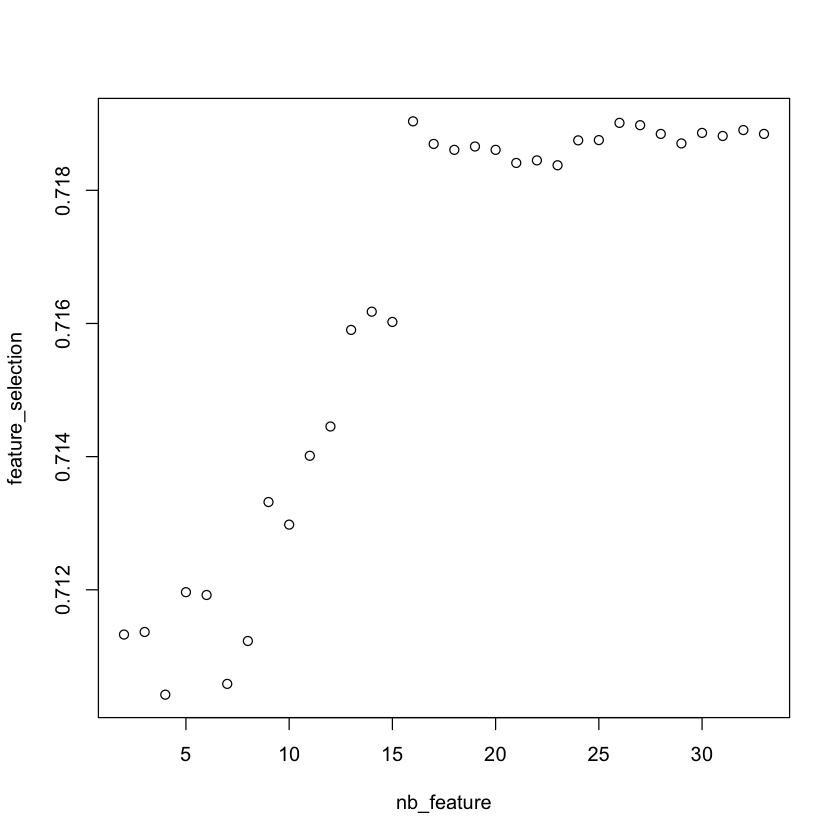

In [35]:
set.seed(2)

k = 10
accuracy_matrix <- matrix(0, nrow = (length(seq(2,length(rankingNN.lin),1))), ncol = k)

tic()
pb1 <- txtProgressBar(min = 1, max = (length(seq(2,length(rankingNN.lin),1))-1), style = 3)

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])


for (l in seq(2,length(rankingNN.lin),1)){
    X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X <- X[,rankingNN.lin[1:l]]
    
    Shuffle_idx <- sample(1:nrow(dataNN.lin))
    max <- ceiling(nrow(dataNN.lin)/k)
    splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    tic()
    for (i in 1:k){
        X.test <- X[splits[[i]],]
        y.test <-  y[splits[[i]],]
        X.train <- X[-splits[[i]],]
        y.train <-  y[-splits[[i]],]
    
        X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

        beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
        pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

        cm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:nrow(X.test)){
            cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1
        }
        TP <- c(cm[1,1],cm[2,2],cm[3,3])
        FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
        FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix[l-1,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
        
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))
    }
    setTxtProgressBar(pb1, l-1)
    print(mean(accuracy_matrix[l-1,]))
    toc()
}

Let us plot the graph of the F1 score as a function of the number of features used.


In [ ]:
feature_selection <- accuracy_matrix %*% as.vector(rep(1/k,k))
nb_feature <- seq(2,length(rankingNN.lin),1)
plot(nb_feature,feature_selection)

We can notice in the plot that sometimes, adding a features creates a little drop in F1 score. We have removed the features responsible for this trend, namely 'has\_superstructure\_mud\_mortar\_stone', 'roof\_type\_n', 'ground\_floor\_type\_x', 'has\_superstructure\_timber', 'position\_j', 'height\_percentage', 'position\_s'. This had the effect of increasing the F1 score further.

In [37]:
set.seed(2)

k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

X <- X[,rankingNN.lin[-c(10,18,29,30,31,32,33)]]

for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.7190435


In this form, there are no parameters to adjust, so we will stop here. We notice that this score is already not so bad, even with a model as simple as the linear model.


### 2.2 Neural network

Let us now continue with a neural network model, using the package keras. 
In this framework, the main tunable parameters: 
- the amount of layers in our neural network
- the amount of neurons per layer
- the learning rate of the neurons
- the amount of epochs during which we will train the network
- the activation function 

We will start by tuning these parameters. As always, we start by a simple value and keep increasing the complexity until it doesn't make our model significantly more performant.
In our case, there is a restriction arising owing to the fact that we deal with multiclass classification problem: we are required to use the softmax activation function for the last output layer.

The most simple configuration, a single dense output layer, with the number of nodes equal to the number of outputs, is actually a linear regression.
We will then try a single layer of a single node, and assess the change of performance of the model when increasing the amount of nodes thanks to an average of the F1 Score among a k-fold CV (with $k \in [5,10]$ ). The choice of using a lower k for some scans is only motivated by time-saving arguments. 
We will proceed in the same manner for the amount of layers, and for the learning rate. While we will use the F1 score to assess the performance of the algorithm, the neural network will be trained using the area under the curve (AUC) of the receiver operator characteristic (ROC) curve as a performance indicator. This is mainly due to uncertainties about the implementation of the F1 score in keras (it required to obtain a vector of values of length equal to the number of rows, but we were unsure about how it was going to be processed, and seemed also computationally suboptimal).

The loss function is the categorical cross-entropy, which is particularly adapted to multiclass classification with one hot encoded variables. It is defined by

$$ L_{CE} =  \sum^n_{i=1} t_i \log_2(p_i) $$ 

where $p_i$ is the softmax probability of the $ i^{th} $ class, and $ t_i $ is the corresponding true label. The softmax probability arises from a generalization of the logistic equation for multiple classes.

The default choice of activation function for hidden layers (neither input or output layers) is a ReLU activation function. We will not investigate this.

Before anything, we will need to create a custom function. The output of the neural network is a 3 columns dataframe, with each building getting a probability of belonging to each class. We will need to convert this to a prediction: we will take the class with highest probability as the prediction. We also define the normalization layer, that will ensure that for each epoch, the values processed by the neural network stay normalized.

In [26]:
#This function converts a dataframe containing class probabilities and one hot encoded labels into a single column of predictions
classConverter <- function(predict_data,test_data) {
    yhat<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    y<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    for (i in 1:nrow(predict_data)){
        yhat[i,]<-which.max(predict_data[i,]) #Prediction probabilities, we choose the max probability as prediction
        y[i,]<-which.max(test_data[i,])  #Validation labels which are one hot encoded
    }
    mylist <- list(yhat,y)
}

For a single layer, let us try first a common heuristics: the amount of nodes should be between the number of inputs and the number of outputs. For this reason, we have tried the average. The learning rate is kept as it was in the practicals.

In [29]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)
targets<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)

normalizer<-layer_normalization(axis = -1L)  %>% #We define the normalization layer of our neural network
adapt(as.matrix(dataNN[,-targets]))
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>%  #We define the neural network model architecture
    normalizer  %>% 
    layer_dense(37, activation = 'relu') %>%  
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   
    
    #We fit our neural network model on our training data
    model_history <- neuralmodel %>% fit(   #We fit the model on the training set chosen
    as.matrix(train_data[,-targets]),
    as.matrix(train_data[,targets]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 100
    )
    
    #We predict the target for the test split of our data
    yhat <- predict(neuralmodel, as.matrix(test_data[-targets]))
    #We convert the probability dataframe into a prediction dataframe
    yhaty <- classConverter(yhat,test_data)
    
    #We compute the F1 score for this fold
    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    
    setTxtProgressBar(pb, i)
    
    print(paste("F1-Score Micro -",i,"fold -", 100,'epochs:',accuracy_vec[i]))
    
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    
    rm('neuralmodel','model_history')
    #We flush the memory as not doing it while running successively multiple model could crash our computers.
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

  |                                                                      |   0%

ERROR: Error in if (tensorflow::tf_version() >= "2.0") tensorflow::tf$is_tensor(x) else tensorflow::tf$contrib$framework$is_tensor(x): l'argument est de longueur nulle


This yield a mean F1-Score over the 5 folds of  0.75477, which is already an improvement over the linear model. We can visualize the learning process thanks to these graphs of the AUC and loss over the course of the folds:

<img src="ezgif-1-f460a89f54.gif" height="500px" />

One of the first things we can notice is that the number of epochs used should not be excessive. Indeed, the accuracy and the loss functions saturate quite fast. Their curve however still keeps a slightly growing trend. For this reason, we decide to not stop the training immediately after the saturation, but after around 30\-50 epochs, which is computationally reasonable. Additionnally, this configuration seems to be overfitting.

Let us try to fix this issue by reducing the complexity of the model. We try to compute a model with less nodes:

In [ ]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)
targets<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)

normalizer<-layer_normalization(axis = -1L)  %>% #We define the normalization layer of our neural network
adapt(as.matrix(dataNN[,-targets]))

# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>%  #We define the neural network model architecture
    normalizer  %>% 
    layer_dense(15, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(    #We fit the model on the training set chosen
    as.matrix(train_data[,-targets]),
    as.matrix(train_data[,targets]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 100
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-targets])) #We predict the target for the test split of our data


    yhaty <- classConverter(yhat,test_data) #We convert the probability dataframe into a prediction dataframe


    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,]) #We compute the F1 score for this fold

    
    setTxtProgressBar(pb, i)
    
    print(paste("F1-Score Micro -",i,"fold -", 100,'epochs:',accuracy_vec[i]))
    
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history') #We flush the memory as not doing it while running successively multiple model could crash our computers.
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

The mean F1 score is now 0.75554, and the model is less overfitting. We can clearly observe it on the graphs shown below, animated over the course of the folds.

<img src="ezgif-1-564cb8dc45.gif" height="500px" />

In order to be able to visualize better the effect of the variation of the parameters, we will continue with 37 nodes in the following. First, let us see if reducing the amount of epochs during which to model is trained changes something.

In [ ]:
set.seed(2)
k = 10

accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)
targets<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

normalizer<-layer_normalization(axis = -1L)  %>% #We define the normalization layer of our neural network
adapt(as.matrix(dataNN[,-targets]))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in 6:6){
        
        neuralmodel <- keras_model_sequential() %>% #We define the neural network model architecture
        normalizer  %>% 
        layer_dense(35, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(0.001),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]


        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(   #We fit the model on the training set chosen
        as.matrix(train_data[,-targets]),
        as.matrix(train_data[,targets]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 5*j
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-targets])) #We predict the target for the test split of our data

        yhaty <- classConverter(yhat,test_data) #We convert the probability dataframe into a prediction dataframe

        accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])  #We compute the F1 score for this fold
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -", 5*j,'epochs:',accuracy_vec[i]))
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history') #We flush the memory as not doing it while running successively multiple model could crash our computers.
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

With a mean F1 score of 0.75588, this does seem to reduce slightly the overfit on the graphs shown below, animated over the course of the folds:

<img src="ezgif-1-cd07b78b2c.gif" width="500px" />

Let us also try to see the influence of the learning rate on this training. We will try to vary it among common value, ranging from 1e-4 to 5e-3.

In [ ]:
set.seed(2)
k = 5

accuracy_vec <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec)<-c('fold','learning_rate','F1')

targets<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)

normalizer<-layer_normalization(axis = -1L)  %>% #We define the normalization layer of our neural network
adapt(as.matrix(dataNN[,-targets]))

# 3. For each unique group:
for (i in 1:k){
    for (j in c(0.0001,0.0005,0.001,0.005)){
        
        neuralmodel <- keras_model_sequential() %>%  #We define the neural network model architecture
        normalizer  %>% 
        layer_dense(37, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(j),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]

        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit( #We fit the model on the training set chosen
        as.matrix(train_data[,-targets]),
        as.matrix(train_data[,targets]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 50
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-targets])) #We predict the target for the test split of our data

        yhaty <- classConverter(yhat,test_data) #We convert the probability dataframe into a prediction dataframe
        
        accuracy_vec[nrow(accuracy_vec)+1,]<-c(i,j,F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])) #We compute the F1 score for this fold
        
        setTxtProgressBar(pb, i)
        
        print(paste("F1-Score Micro -",i,"fold -",'Learning rate',j,': ',accuracy_vec[nrow(accuracy_vec),3]))
        
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',main=paste('Learning rate:',j, '1 layer of 37', 'fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',main=paste('Learning rate:',j, '1 layer of 37', 'fold', i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        
        rm('neuralmodel','model_history')  #We flush the memory as not doing it while running successively multiple model could crash our computers.
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
meanF1 <- data.frame(matrix(ncol = 2, nrow = 0))
colnames(meanF1)<-c('learning_rate','mean F1')
for (i in c(0.0001,0.0005,0.001,0.005)){
    meanF1[nrow(meanF1)+1,]<-c(i,mean(filter(accuracy_vec,(learning_rate==i))$F1))
}

accuracy_vec
meanF1

The results are summarized in this table, averaged over the folds:

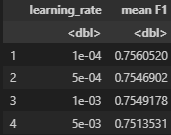

This is visually confirmed by the traning curves animated over the course of the folds for each parameter which shows way less noise in the training with the lowest learning rate:

<img src="ezgif-1-10882c2598.gif" width='400px' />
<img src="ezgif-1-dad390135e.gif"  width='400px' />
<img src="ezgif-1-2c78e9a7bb.gif" width='400px'/>
<img src="ezgif-1-7d6a860c88.gif"  width='400px' />

Let us check if increasing the amount of nodes to be equal to the amount of inputs enhances or worsens our model.  



In [ ]:
set.seed(2)
k = 10

accuracy_vec2 <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec2)<-c('fold','learning_rate','F1')
targets<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

normalizer<-layer_normalization(axis = -1L)  %>% #We define the normalization layer of our neural network
adapt(as.matrix(dataNN[,-targets]))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in c(0.0001,0.0005,0.001,0.005)){
        
        neuralmodel <- keras_model_sequential() %>%  #We define the neural network model architecture
        normalizer  %>% 
        layer_dense(70, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(j),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]

        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(  #We fit the model on the training set chosen
        as.matrix(train_data[,-targets]),
        as.matrix(train_data[,targets]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 50
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-targets])) #We predict the target for the test split of our data

        yhaty <- classConverter(yhat,test_data)#We convert the probability dataframe into a prediction dataframe
        
        accuracy_vec2[nrow(accuracy_vec2)+1,]<-c(i,j,F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])) #We compute the F1 score for this fold
        setTxtProgressBar(pb, i)
        
        print(paste("F1-Score Micro -",i,"fold -",'Learning rate',j,': ',accuracy_vec2[nrow(accuracy_vec2),3]))
        
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',main=paste('Learning rate:',j, '1 layer of 70','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',main=paste('Learning rate:',j, '1 layer of 70','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history') #We flush the memory as not doing it while running successively multiple model could crash our computers.
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
meanF1_2 <- data.frame(matrix(ncol = 2, nrow = 0))
colnames(meanF1_2)<-c('learning_rate','mean F1')
for (i in c(0.0001,0.0005,0.001,0.005)){
    meanF1_2[nrow(meanF1_2)+1,]<-c(i,mean(filter(accuracy_vec2,(learning_rate==i))$F1))
}

accuracy_vec2
meanF1_2


As previously, the results are summarized in the following, which shows that this does not make our model better at predicting, with a slight increase in overfitting.

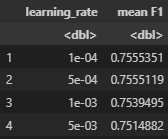

<img src="ezgif-1-0f07722fb6.gif" width='500px' />

<img src="ezgif-1-e675206ff2.gif" width='500px' />

<img src="ezgif-1-c17523f4a6.gif" width='500px' />

<img src="ezgif-1-88305f4d02.gif" width='500px' />

Instead of increasing the amount of nodes, let us try to increase the amount of layers. We will assess what happens with two layers of 37 nodes. As seen before, a high learning rate seems consistently worse. We thus focus on the lowest learning rates available.

In [ ]:
set.seed(2)
k = 10

accuracy_vec3 <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec3)<-c('fold','learning_rate','F1')

targets<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)

normalizer<-layer_normalization(axis = -1L)  %>% #We define the normalization layer of our neural network
adapt(as.matrix(dataNN[,-targets]))
# 3. For each unique group:
for (i in 1:k){
    for (j in c(0.0001,0.0005)){
        
        neuralmodel <- keras_model_sequential() %>%  #We define the neural network model architecture
        normalizer  %>%  
        layer_dense(37, activation = 'relu') %>%
        layer_dense(37, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(j),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]

        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit( #We fit the model on the training set chosen
        as.matrix(train_data[,-targets]),
        as.matrix(train_data[,targets]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 50
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-targets]))  #We predict the target for the test split of our data

  
        yhaty <- classConverter(yhat,test_data)#We convert the probability dataframe into a prediction dataframe
        
        accuracy_vec3[nrow(accuracy_vec3)+1,]<-c(i,j,F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])) #We compute the F1 score for this fold
        
        setTxtProgressBar(pb, i)
        
        print(paste("F1-Score Micro -",i,"fold -",'Learning rate',j,': ',accuracy_vec3[nrow(accuracy_vec3),3]))
        
        
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',main=paste('Learning rate:',j, '2 layers of 35','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',main=paste('Learning rate:',j, '2 layers of 35','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history') #We flush the memory as not doing it while running successively multiple model could crash our computers.
    }
}
meanF1_3 <- data.frame(matrix(ncol = 2, nrow = 0))
colnames(meanF1_3)<-c('learning_rate','mean F1')
for (i in c(0.0001,0.0005)){
    meanF1_3[nrow(meanF1_3)+1,]<-c(i,mean(filter(accuracy_vec3,(learning_rate==i))$F1))
}
accuracy_vec3
meanF1_3

As before, the results are summarized here (please note that there is a typo in the titles of the graphs, and it is 37 nodes, not 35):

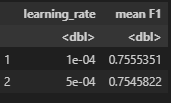

<img src="ezgif-1-3dceaba44c.gif" width='500px' />

<img src="ezgif-1-d85615b3df.gif" width='500px'/>

We can notice that adding more layers or increasing the complexity does not seem to help the accuracy of the problem at all. 

The course syllabus however mentioned that deep NN were often the most performing ones. As such, we will also try a model with multiples layer and a very low number of nodes.

In [ ]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)
targets<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)

normalizer<-layer_normalization(axis = -1L)  %>% #We define the normalization layer of our neural network
adapt(as.matrix(dataNN[,-targets]))
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>%  #We define the neural network model architecture
    normalizer  %>% 
    layer_dense(5, activation = 'relu') %>%
    layer_dense(5, activation = 'relu') %>%
    layer_dense(5, activation = 'relu') %>%
    layer_dense(5, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(  #We fit the model on the training set chosen
    as.matrix(train_data[,-targets]),
    as.matrix(train_data[,targets]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 50
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-targets])) #We predict the target for the test split of our data

    yhaty <- classConverter(yhat,test_data) #We convert the probability dataframe into a prediction dataframe

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,]) #We compute the F1 score for this fold
    
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 50,'epochs:',accuracy_vec[i]))
    
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history') #We flush the memory as not doing it while running successively multiple model could crash our computers.
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec))) 

This yields a mean F1 score over 5 folds of 0.7537, which is resonable but not better than what we have seen previously. We can however notice an interesting trend, that we have observed on other tries with deep shallow layers: there can be seemingly be a threshold on the precision, which suddenly starts to raise again after enough epochs. This could indicate that we should have trained there models for a longer amount of epochs.

<img src="ezgif-1-a9d561ca0b.gif" width='500px' />

Considering that neural networks were not so computationally expensive, we did not start with feature selection. However, it could still have saved some time. Indeed, we can use rMRM ranking computed in the introduction, and compute the F1 score adding features along this ranking.

In [ ]:
# drop = F is used to preserve the structure of the data as data.frame (see https://www.r-bloggers.com/2018/02/r-tip-use-drop-false-with-data-frames/)
set.seed(2) 
CV_folds <- 5
targets<-which(grepl('damage_grade',colnames(dataNN)))
n<-ncol(dataNN[,-targets])
N<-nrow(dataNN[,-targets])
size_CV <-floor(N/CV_folds)

accuracy_vec <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec)<-c('n','fold','F1')


for (nb_features in seq(2,n,5)) {
    for (i in 1:CV_folds) {
    
        targets<-which(grepl('damage_grade',colnames(dataNN)))
        idx_ts<-(((i-1)*size_CV+1):(i*size_CV))  ### idx_ts represents the indices of the test set the i-th fold
        X_ts<-dataNN[idx_ts,-targets]  
        Y_ts<-dataNN[idx_ts,targets]      
        
        idx_tr<-setdiff(1:N,idx_ts) ### idx_tr represents  indices of the training sefor the i-th fold
        X_tr<-dataNN[idx_tr,-targets]
        Y_tr<-dataNN[idx_tr,targets]                          

        # Create a dataset including only the first nb_features selected variables
        DS<-cbind(X_tr[,rankingNN[1:nb_features],drop=F],Y_tr)
        
        # Model fit (using lm function)
        targets<-which(grepl('damage_grade',colnames(DS)))
        normalizer<-layer_normalization(axis = -1L)  %>%  
        adapt(as.matrix(DS[,-targets]))

        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(37, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(0.001),
            metrics=c('AUC')
        )
        
        model_history <- neuralmodel %>% fit(
        as.matrix(DS[,-targets]),
        as.matrix(DS[,targets]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 30
        )

        # Model prediction
        yhat <- predict(neuralmodel, as.matrix(X_ts[,rankingNN[1:nb_features]]))

        yhaty <- classConverter(yhat,Y_ts)
 
        accuracy<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
        
        # Cross-validation error = F1
        accuracy_vec[nrow(accuracy_vec)+1,]<-c(nb_features,i,accuracy)
        print(paste("F1-Score Micro -",i,"fold -", nb_features,'features:',accuracy))
        rm('neuralmodel','model_history')
    }
}

accuracy_vec


,n,mean F1
,<dbl>,<dbl>
1,2,0.7350102
2,7,0.7501485
3,12,0.7532773
4,17,0.7538752
5,22,0.7545658
6,27,0.7542224
7,32,0.7544771
8,37,0.7547394
9,42,0.7549940


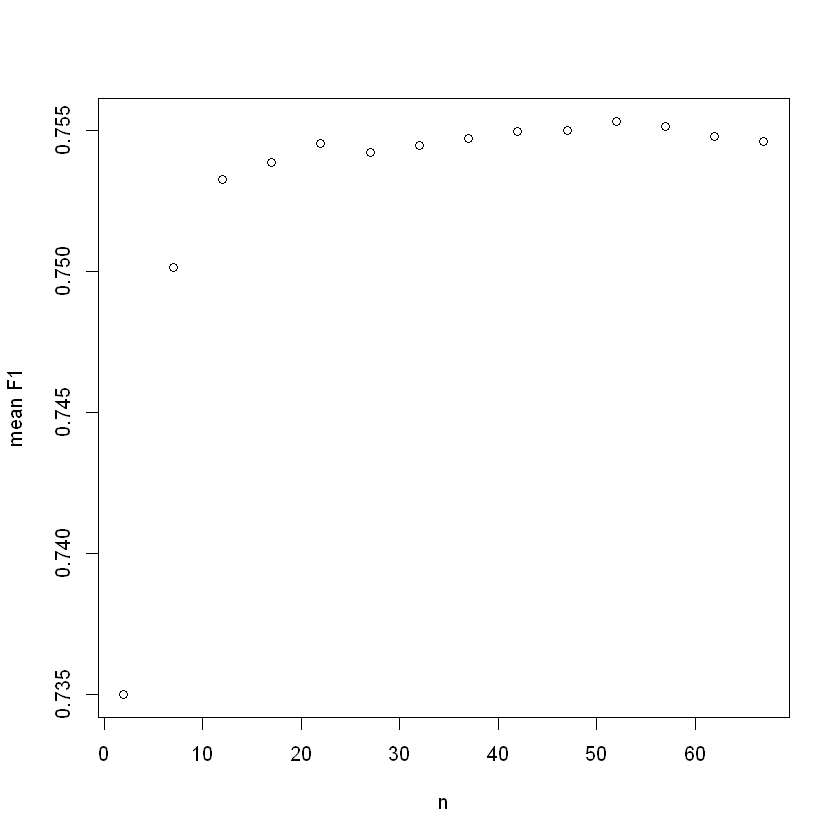

In [ ]:
meanF1 <- data.frame(matrix(ncol = 2, nrow = 0))

colnames(meanF1)<-c('n','mean F1')
    for (l in seq(2,nb_features,5)){
            meanF1[nrow(meanF1)+1,]<-c(l,mean(filter(accuracy_vec,(n==l))$F1))
    }
    plot(meanF1)
meanF1

We notice that we could limit ourselves to 22 features while keeping a precision for our model almost as good as with the whole dataset.

### 2.3 Random forest

We will now implement a random forest method, which is one of the most used classifiers. There are two tunable parameters:

- the amount of trees used by the random forest, n\_trees
- the amount of features randomly selected at each split, mtry

Before scanning these parameters to try to find an optimal value, let us check the relevance of the features, which is easily computable by using the randomForest package method rfcv. This creates a list of variable ranked by importance by the RF algorithm itself, and then performs a k\-fold CV validation to compute the error when adding features following the created importance ranking. We will try that for multiple tree numbers. We apply this function for a few different values of the number of trees, using the default value for mtry \(max\(1,log\(p\)\) where p is the number of features considered\).

First, let us compute the variable importance plot \(varImpPlot function in the randomFores  
t package\):


In [ ]:
set.seed(2)
options(repr.plot.width=31, repr.plot.height=9)
n_trees <- 20
nfeat <- ncol(data)-1 #We remove 1 to remove damage_grade
nrows<-nrow(data)
target_variable <- match('damage_grade', colnames(data))

model <- randomForest(x=data[,-c(target_variable)],
                    y=as.factor(data[,c(target_variable)]),  #We make sure to encode the target as a factor, so randomForest recognize the problem as multiclass
                    ntree=n_trees,keep.forest=TRUE,importance=TRUE)

varImpPlot(model)

<img src="varImpPlot.png" style="max-width:100%" />


We can see that the target encoded variable are among the most important ones, confirming this choice, even if they may be too important and subject to overfitting. We can also notice that some variable were intuitively expected, as it is natural they would affect the results of an earthquake, namely:

- the age of the buildings
- if the building has a structure made of timber, as it is known wood buildings withstand earthquakes better
- the surface and height the building
- the type of foundations used for the building

We can now use the rfcv function to assess the change in performance of the model while removing features following this ranking.  



In [4]:
set.seed(2)
n_trees <- 20

data_idx <- sample(1:nrow(data)) #Randomized indices for rows
split <- floor(nrow(data)*0.8)

target_variable <- match('damage_grade', colnames(data))
train_data <- data[data_idx[1:split],]
test_data <- data[data_idx[(split+1):nrow(data)],] #We perform a 80-20 split of the data to cross-validate

cv_RF<-rfcv(train_data[,-c(target_variable)],as.factor(train_data[,c(target_variable)]),cv.fold=10,ntree=n_trees)

with(cv_RF, plot(n.var, error.cv, log="x", type="o", lwd=2))

ERROR: Error in 1:nrow(data): argument of length 0


<img src="RFCV1.png"   width="500 px" style="object-fit:cover"/>


In [ ]:
set.seed(2)
n_trees <- 50
data_idx <- sample(1:nrow(data)) #Randomized indices for rows

split <- floor(nrow(data)*0.8)
target_variable <- match('damage_grade', colnames(data))

train_data <- data[data_idx[1:split],]
test_data <- data[data_idx[(split+1):nrow(data)],] #We perform a 80-20 split of the data to cross-validate

cv_RF<-rfcv(train_data[,-c(target_variable)],as.factor(train_data[,c(target_variable)]),cv.fold=10,ntree=n_trees)

with(cv_RF, plot(n.var, error.cv, log="x", type="o", lwd=2))

<img src="RFCV2.png"   width="500px"  style="object-fit:cover"/>



In [ ]:
set.seed(2)
n_trees <- 200

data_idx <- sample(1:nrow(data)) #Randomized indices for rows
split <- floor(nrow(data)*0.8) 

target_variable <- match('damage_grade', colnames(data))

train_data <- data[data_idx[1:split],]
test_data <- data[data_idx[(split+1):nrow(data)],]  #We perform a 80-20 split of the data to cross-validate

cv_RF<-rfcv(train_data[,-c(target_variable)],as.factor(train_data[,c(target_variable)]),cv.fold=5,ntree=n_trees)

with(cv_RF, plot(n.var, error.cv, log="x", type="o", lwd=2))

<img src="RFCV3.png"   width="500px"  style="object-fit:cover"/>


We can notice that in this framework, removing any feature leads to a significant drop in accuracy. We therefore choose to keep all of the features while working with random forests. We now move on to tuning the parameters.For this, we have performed loops on some values of the hyperparameters. We have separated this in two loops, due to computational time reasons. In the second loop, we do not try all of the values of mtry again, only keeping the ones that performed the best in the first loop.  



In [ ]:
set.seed(2)
k = 10

nfeat <- ncol(data)-1 #I remove 1 to remove damage_grade

n_trees <- c(10,20,100)
m_tries <- c(floor(0.5*sqrt(nfeat)),floor(sqrt(nfeat)),floor(2*sqrt(nfeat)))

accuracy_vec <- data.frame(matrix(ncol = 4, nrow = 0))
colnames(accuracy_vec)<-c('fold','n_trees','mtry','F1')

nrows<-nrow(data)

data_idx <- sample(1:nrows) #Randomized indices for rows

target_variable <- match('damage_grade', colnames(data))
pb <- txtProgressBar(min = 0, max = length(n_trees), style = 3)

# 1. Shuffle the dataset randomly.
data_idx <- sample(1:nrow(data))

# 2. Split the dataset into k groups
max <- ceiling(nrow(data)/k)
splits <- split(data_idx, ceiling(seq_along(data_idx)/max))

pb <- txtProgressBar(min = 0, max = k*length(n_trees)*length(m_tries), style = 3)
counter <-0

# 3. For each unique group:
for (i in 1:k){
    for (j in (n_trees)){
        for (l in m_tries){
            #3.1 Take the group as a hold out or test data set
            test_data <- data[splits[[i]],]


            #3.2 Take the remaining groups as a training data set
            train_data <- data[-splits[[i]],]   

            model <- randomForest(x=train_data[,-c(target_variable)],   #We fit the model on the training set chosen
                                y=as.factor(train_data[,c(target_variable)]),
                                ntree=j,mtry=l,keep.forest=TRUE,importance=TRUE)
            
            yhat<-predict(model,test_data[,-c(target_variable)]) #We predict the target for the kth fold
            
            accuracy_vec[nrow(accuracy_vec)+1,]<-c(i,j,l,F1_Score_micro(as.factor(test_data[,c(target_variable)]),yhat)) #We compute the F1 score for this fold
            
            counter<-counter+1
            setTxtProgressBar(pb, counter)
            
            print(paste("Best F1 Score - ",i, 'fold',j,'trees',l,'mtry',':',accuracy_vec[nrow(accuracy_vec),4]))
            rm('model') #We flush the memory as not doing it while running successively multiple model could crash our computers.
        }
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
meanF1 <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(meanF1)<-c('n_trees','mtry','mean F1')
for (i in n_trees){
    for (j in m_tries){
            meanF1[nrow(meanF1)+1,]<-c(i,j,mean(filter(accuracy_vec,(n_trees==i & mtry==j))$F1))
    }
}
accuracy_vec
meanF1

In [ ]:
set.seed(2)
k = 10

n_trees <- c(200,500)
m_tries <- c(floor(0.5*sqrt(nfeat)),floor(sqrt(nfeat)))


nfeat <- ncol(data)-1 #I remove 1 to remove damage_grade

accuracy_vec <- data.frame(matrix(ncol = 4, nrow = 0))
colnames(accuracy_vec)<-c('fold','n_trees','mtry','F1')

nrows<-nrow(data)

target_variable <- match('damage_grade', colnames(data))
pb <- txtProgressBar(min = 0, max = length(n_trees), style = 3)

# 1. Shuffle the dataset randomly.
data_idx <- sample(1:nrow(data))

# 2. Split the dataset into k groups
max <- ceiling(nrow(data)/k)
splits <- split(data_idx, ceiling(seq_along(data_idx)/max))

pb <- txtProgressBar(min = 0, max = k*length(n_trees)*length(m_tries), style = 3)
counter <-0

# 3. For each unique group:
for (i in 1:k){
    for (j in (n_trees)){
        for (l in m_tries){
            #3.1 Take the group as a hold out or test data set
            test_data <- data[splits[[i]],]


            #3.2 Take the remaining groups as a training data set
            train_data <- data[-splits[[i]],]   

            model <- randomForest(x=train_data[,-c(target_variable)],  #We fit the model on the training set chosen
                                y=as.factor(train_data[,c(target_variable)]),
                                ntree=j,mtry=l,keep.forest=TRUE,importance=TRUE)
            yhat<-predict(model,test_data[,-c(target_variable)])
            
            accuracy_vec[nrow(accuracy_vec)+1,]<-c(i,j,l,F1_Score_micro(as.factor(test_data[,c(target_variable)]),yhat)) #We compute the F1 score for this fold
            
            counter<-counter+1
            setTxtProgressBar(pb, counter)
            
            print(paste("Best F1 Score - ",i, 'fold',j,'trees',l,'mtry',':',accuracy_vec[nrow(accuracy_vec),4]))
            rm('model') #We flush the memory as not doing it while running successively multiple model could crash our computers.
        }
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
meanF1 <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(meanF1)<-c('n_trees','mtry','mean F1')
for (i in n_trees){
    for (j in m_tries){
            meanF1[nrow(meanF1)+1,]<-c(i,j,mean(filter(accuracy_vec,(n_trees==i & mtry==j))$F1))
    }
}
accuracy_vec
meanF1

The results of these two cells are summarized in the following two tables:

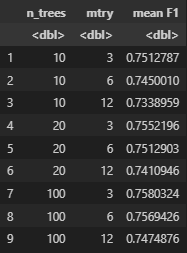
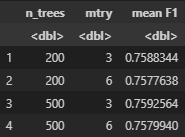



These tables show the F1 averaged over a 10\-fold cross validation for each of the parameter combination shown. As we can see, the optimal mtry value is always $ \frac{1}{2}\log(p)$. Concerning the number of trees, the mean F1 score keeps increasing at it rises. However, we can see that the increase in F1 score becomes limited as we reach n\_trees = 100. For this reason, the significant computational cost of going into n\_trees higher than 500 does not seem to be worth it.  

In this case, increasing the complexity of the model does not seem to lead to overfitting. The results obtained here are quite good, the best score on the leaderboard of the DrivenData competition being only 0.7558. It has to be noted that the score obtained on DrivenData is always significantly smaller than the score computed by our means, in a cross\-validation. This could be due to a choice of data that are different than the training values, to assess the capacity of our models to extrapolate on not previously seen data.   



### 2.4 Comparison of models

We compare our models on the basis of the mean F1 score obtained during a 5 or 10\-fold CV for the optimal parameters that we found during the tuning phases.

We found the following scores:

- Linear model: 0.7194216
- Neural Network: 0.7560520 (1 layer of 37 nodes with a learning rate of 0.0001)
- Random Forest: 0.7592564 (500 trees with 0.5log(p)=3 features selected at each split)

However, these results must be interpreted carefully. We have noticed that depending on the model, the score obtained on DrivenData could change quite a lot. This is probably because the test set contains features unseen by our model in the train set. This difference could thus represent the ability of our model to extrapolate on types of data it has not seen before, task at which some models are better than others. 

Selecting merely on the basis of the k-folded F1 score, we would select the Random Forest method to treat this problem. 
This is also the model that has performed the best on DrivenData.


# 3. Implementation of an other learning procedure



### 3.1 Gradient boosted tree

As an additional learning process, we decided to test the gradient boosting tree using the xgboost package, which is known to often outperform random forest for classification tasks due to a more refined algorithm that uses previous attemps to optimize the parameters. 

We are also going to use the caret package to run xgboost, this will be very useful for the tunings of the parameters. Although at first we won't use any of the caret's features.


In [6]:
data.xgb <- read.csv("data_target_encoding.csv",stringsAsFactors = T)
test.xgb <- read.csv("test_target_encoding.csv",stringsAsFactors = T)

To feed our data to xgboost, we will need to use the S4 format. This format caused some issues with the computation of the mRMR, so we will keep  data.xgb that will be one hot encoded and then not be encoded as S4.


In [7]:
dummy_data <- dummyVars(" ~ .", data=data.xgb)  
data.xgb <- data.frame(predict(dummy_data, newdata = data.xgb)) 
dummy_test <- dummyVars(" ~ .", data=test.xgb)  
test.xgb <- data.frame(predict(dummy_test, newdata = test.xgb)) 

Note that if we had not done the dummy encoding before, the sparces.model.matrix function would have automatically done it using the dummy contrast coding. For the sake of consistency we prefer to use the same dummy encoding everywhere. 

For more information on contrast coding, see: [https://stats.oarc.ucla.edu/r/library/r\-library\-contrast\-coding\-systems\-for\-categorical\-variables/](https://stats.oarc.ucla.edu/r/library/r-library-contrast-coding-systems-for-categorical-variables/) 


In [2]:
X <- sparse.model.matrix(damage_grade ~ .,data = data.xgb)[,-1]
test.xgb <- sparse.model.matrix( ~ .,data = test.xgb)[,-1]
y <- as.numeric(data.xgb[,c("damage_grade")]-1)

ERROR: Error in sparse.model.matrix(damage_grade ~ ., data = data.xgb): could not find function "sparse.model.matrix"


In [72]:
typeof(X)

[1] "S4"

Just to get a feel of the performance of this model, let us try to perform a xgboost prediction through a 5\-fold CV without any tuning.


In [80]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

Shuffle_idx <- sample(1:nrow(X))
max <- ceiling(nrow(X)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 

tic()
pb2 <- txtProgressBar(min = 1, max = k, style = 3)

for (i in 1:k){
    
    X.test <- X[splits[[i]],]
    y.test <- y[splits[[i]]]
    X.train <- X[-splits[[i]],]
    y.train <- y[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )

    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.train,
    y = as.factor(y.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.test)
    ll <- length(y.test)
    cm <- matrix(0, nrow = 3, ncol = 3) # cm is the confusion matrix 
    # 
    for (j in 1:ll){cm[pred[j],(y.test[j]+1)] <- cm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
}

mean(accuracy_vec)
toc()

  |                                                                      |   0%[1] 0.762706
  |==================                                                    |  25%[1] 0.7585618
  |===================================                                   |  50%[1] 0.7631089
  |====================================================                  |  75%[1] 0.7621112
  |======================================================================| 100%[1] 0.761383


[1] 0.7615742

663.61 sec elapsed


The results are already quite good. Let us now try to see if the unbalanceness of the damage\_grade target affects significantly this score. Let us first try to peform the subsample strategy.  



In [81]:
set.seed(2)

k = 5
accuracy_vec.sub <- array(0,k)

Shuffle_idx <- sample(1:nrow(data.xgb))
max <- ceiling(nrow(data.xgb)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 

tic()
pb2 <- txtProgressBar(min = 1, max = k, style = 3)

for (i in 1:k){
    
    data.test <- data.xgb[splits[[i]],]
    data.train <- data.xgb[-splits[[i]],]
    
    idx_damage_grade_1 <- which(data.train$damage_grade == 1)
    n_sub <- length(idx_damage_grade_1)

    idx_damage_grade_2 <- sample(which(data.train$damage_grade == 2),n_sub)
    idx_damage_grade_3 <- sample(which(data.train$damage_grade == 3),n_sub)
    
    data.sub.train <- rbind(data.train[idx_damage_grade_1,],data.train[idx_damage_grade_2,],data.train[idx_damage_grade_3,])
    

    X.sub.train <- sparse.model.matrix(damage_grade ~ .,data = data.sub.train)[,-1]
    X.test <- sparse.model.matrix(damage_grade ~ .,data = data.test)[,-1]
    y.sub.train <- as.numeric(data.sub.train[,c("damage_grade")]-1)
    y.test <- as.numeric(data.train[,c("damage_grade")]-1)
    
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )

    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model.sub <- caret::train(
    x = X.sub.train,
    y = as.factor(y.sub.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model.sub, X.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    
    accuracy_vec.sub[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
}

mean(accuracy_vec.sub)
toc()

  |                                                                      |   0%[1] 0.3908789
  |==================                                                    |  25%[1] 0.3942365
  |===================================                                   |  50%[1] 0.3903993
  |====================================================                  |  75%[1] 0.3939487
  |======================================================================| 100%[1] 0.3937679


[1] 0.3926462

198.356 sec elapsed


The result got significantly worse, so that we will not pursue this lead. 

We now try to perform the oversample strategy.


In [82]:
set.seed(2)

k = 5
accuracy_vec.over <- array(0,k)

Shuffle_idx <- sample(1:nrow(data.xgb))
max <- ceiling(nrow(data.xgb)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 

tic()
pb2 <- txtProgressBar(min = 1, max = k, style = 3)

for (i in 1:k){
    data.test <- data.xgb[splits[[i]],]
    data.train <- data.xgb[-splits[[i]],]
    
    idx_damage_grade_1 <- which(data.train$damage_grade == 1)
    idx_damage_grade_2 <- which(data.train$damage_grade == 2)
    idx_damage_grade_3 <- which(data.train$damage_grade == 3)
    
    n_over1 <- length(idx_damage_grade_2)-length(idx_damage_grade_1)
    n_over3 <- length(idx_damage_grade_2)-length(idx_damage_grade_3)
    
    idx_damage_grade_1 <- sample(idx_damage_grade_1,n_over1,replace=TRUE)
    idx_damage_grade_3 <- sample(idx_damage_grade_3,n_over3,replace=TRUE)
    
    data.over.train <- rbind(data.train[idx_damage_grade_1,],data.train[idx_damage_grade_2,],data.train[idx_damage_grade_3,])
    

    X.over.train <- sparse.model.matrix(damage_grade ~ .,data = data.over.train)[,-1]
    X.test <- sparse.model.matrix(damage_grade ~ .,data = data.test)[,-1]
    y.over.train <- as.numeric(data.over.train[,c("damage_grade")]-1)
    y.test <- as.numeric(data.train[,c("damage_grade")]-1)
    
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )

    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model.over <- caret::train(
    x = X.over.train,
    y = as.factor(y.over.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model.over, X.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    
    accuracy_vec.over[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
}

mean(accuracy_vec.over)
toc()

  |                                                                      |   0%[1] 0.433357
  |==================                                                    |  25%[1] 0.4340669
  |===================================                                   |  50%[1] 0.4315535
  |====================================================                  |  75%[1] 0.4338175
  |======================================================================| 100%[1] 0.4353858


[1] 0.4336361

853.377 sec elapsed


This is still really bad. This indicates that the xgboost method may not very sensitive to unbalanced datasets.  



- Feature selection 

As previously, we will perform a rMRM ranking that we will use to assess the relevance of our variables in the prediction power of this method.  



In [86]:
set.seed(2)

n<-ncol(data.xgb)
targets<-which(grepl('damage_grade',colnames(data.xgb)))
correlation<-abs(cor(data.xgb[,-targets,drop=F],data.xgb[,targets,drop=F]))
selected<-c()
candidates<-1:n

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-abs(cor(data.xgb[,selected,drop=F],data.xgb[,candidates,drop=F]))
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
        # mRMR: minimum Redundancy Maximum Relevancy
        mRMR_score<-correlation[candidates]-redundancy_score
        
        # Select the candidate variable that maximises the mRMR score
        selected_current<-candidates[which.max(mRMR_score)]
        selected<-c(selected,selected_current)
        
        # Remove the selected variables from the candidates
        candidates<-setdiff(candidates,selected_current)
    }
    
ranking.xgb <- selected
ranking.xgb
colnames(data.xgb)[ranking.xgb]

[1]  5 24 22  3  2 50 16  1 18 21 46 15  4 28 27 29 17 19 54 20 53  6  7 51 56
[26]  9 30 58 52 62 47 63 33 45 34 44 37 60 48 59  8 55 64 35 25 36 26 23 42 31
[51] 61 12 13 11 41 14 70 43 10 66 65 68 67 57 39 40 69 38 49 32

[1] "geo_level_3_mean_damage"               
 [2] "ground_floor_type.v"                   
 [3] "ground_floor_type.f"                   
 [4] "geo_level_2_mean_damage"               
 [5] "geo_level_1_sd_damage"                 
 [6] "has_superstructure_cement_mortar_brick"
 [7] "foundation_type.r"                     
 [8] "geo_level_1_mean_damage"               
 [9] "foundation_type.w"                     
[10] "roof_type.x"                           
[11] "has_superstructure_mud_mortar_stone"   
[12] "foundation_type.i"                     
[13] "geo_level_2_sd_damage"                 
[14] "other_floor_type.q"                    
[15] "other_floor_type.j"                    
[16] "other_floor_type.s"                    
[17] "foundation_type.u"                     
[18] "roof_type.n"                           
[19] "has_superstructure_rc_engineered"      
[20] "roof_type.q"                           
[21] "has_superstructure_rc_non_engineered"  
[22] "geo_level_3_sd_damage"                 
[23] "count_floors_pre_eq"                   
[24] "has_superstructure_timber"             
[25] "legal_ownership_status.a"              
[26] "area_percentage"                       
[27] "other_floor_type.x"                    
[28] "legal_ownership_status.v"              
[29] "has_superstructure_bamboo"             
[30] "has_secondary_use_hotel"               
[31] "has_superstructure_stone_flag"         
[32] "has_secondary_use_rental"              
[33] "position.s"                            
[34] "has_superstructure_adobe_mud"          
[35] "position.t"                            
[36] "plan_configuration.u"                  
[37] "plan_configuration.d"                  
[38] "count_families"                        
[39] "has_superstructure_cement_mortar_stone"
[40] "legal_ownership_status.w"              
[41] "age"                                   
[42] "has_superstructure_other"              
[43] "has_secondary_use_institution"         
[44] "plan_configuration.a"                  
[45] "ground_floor_type.x"                   
[46] "plan_configuration.c"                  
[47] "ground_floor_type.z"                   
[48] "ground_floor_type.m"                   
[49] "plan_configuration.q"                  
[50] "position.j"                            
[51] "has_secondary_use_agriculture"         
[52] "land_surface_condition.o"              
[53] "land_surface_condition.t"              
[54] "land_surface_condition.n"              
[55] "plan_configuration.o"                  
[56] "foundation_type.h"                     
[57] "has_secondary_use_other"               
[58] "plan_configuration.s"                  
[59] "height_percentage"                     
[60] "has_secondary_use_industry"            
[61] "has_secondary_use_school"              
[62] "has_secondary_use_gov_office"          
[63] "has_secondary_use_health_post"         
[64] "legal_ownership_status.r"              
[65] "plan_configuration.m"                  
[66] "plan_configuration.n"                  
[67] "has_secondary_use_use_police"          
[68] "plan_configuration.f"                  
[69] "has_superstructure_mud_mortar_brick"   
[70] "position.o"

We add two features at a time to see the progress of the F1 according to the number of features following the order given by the MRMR. 

Can take a long time !


In [ ]:
set.seed(2)

k = 5
accuracy_matrix.xgb <- matrix(0, nrow = length(seq(2,length(ranking.xgb),2)), ncol = k)

tic()
pb1 <- txtProgressBar(min = 1, max = length(seq(2,length(ranking.xgb),2)), style = 3)
for (l in seq(2,length(ranking.xgb),2)){
    
    X.f  <- X[,ranking.xgb[1:l]]
    
    Shuffle_idx <- sample(1:nrow(X.f))
    max <- ceiling(nrow(X.f)/k)
    splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 
    
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
    for (i in 1:k){
        X.f.test <- X.f[splits[[i]],]
        y.test <- y[splits[[i]]]
        X.f.train <- X.f[-splits[[i]],]
        y.train <- y[-splits[[i]]]
    
        grid_default <- expand.grid(
        nrounds = 100,
        max_depth = 6,
        eta = 0.3,
        gamma = 0,
        colsample_bytree = 1,
        min_child_weight = 1,
        subsample = 1
        )
        
        train_control <- caret::trainControl(
        method = "none",
        verboseIter = FALSE, # no training log
        allowParallel = TRUE, # FALSE for reproducible results 
        summaryFunction = multiClassSummary
        )

        xgb_model <- caret::train(
        x = X.f.train,
        y = as.factor(y.train),
        trControl = train_control,
        tuneGrid = grid_default,
        method = "xgbTree",
        verbose = TRUE
        )

        pred <- predict(xgb_model, X.f.test)
        ll <- length(y.test)
        cfm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
        TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
        FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
        FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix.xgb[l/2,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
    }
    setTxtProgressBar(pb1, l/2)
    print(mean(accuracy_matrix.xgb[l/2,]))
    toc()
}

In [ ]:
#write.csv(as.data.frame(accuracy_matrix.xgb), file = "accuracy_matrix_feature_selection_xgb.csv", row.names = FALSE)

In [84]:
accuracy_matrix.xgb <- as.matrix(read.csv("accuracy_matrix_feature_selection_xgb.csv",stringsAsFactors = T))
accuracy_matrix.xgb

V1,V2,V3,V4,V5
0.7387425,0.7350204,0.7415053,0.7395484,0.7389336
0.7403542,0.7378792,0.7391263,0.7421960,0.7413704
0.7441722,0.7411792,0.7435966,0.7431745,0.7431932
0.7443257,0.7468583,0.7491798,0.7451315,0.7446706
0.7468966,0.7507531,0.7464170,0.7435966,0.7480477
0.7511176,0.7485467,0.7469926,0.7474530,0.7488919
0.7525757,0.7490071,0.7510025,0.7499664,0.7471075
0.7516164,0.7505228,0.7519618,0.7527676,0.7472226
0.7502542,0.7530938,0.7492182,0.7515205,0.7510601
0.7537269,0.7470118,0.7509833,0.7500624,0.7511369


In [ ]:
feature_selection <- as.matrix(accuracy_matrix.xgb) %*% as.vector(rep(1/k,k))
nb_feature <- seq(2,length(ranking.xgb),2)
plot(nb_feature,feature_selection)

We can see that some features actually reduce the accuracy of the model when adding them instead of increasing it. Let us try to remove them.  



In [ ]:
set.seed(2)

k = 5
accuracy_vec <- 1:k

tic()

X.f  <- X[,ranking.xgb[-c(13,14,21,22,45,46,51,52)]]
    
Shuffle_idx <- sample(1:nrow(X.f))
max <- ceiling(nrow(X.f)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max)) 
    
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
for (i in 1:k){
    X.f.test <- X.f[splits[[i]],]
    y.test <- y[splits[[i]]]
    X.f.train <- X.f[-splits[[i]],]
    y.train <- y[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )
        
    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.f.train,
    y = as.factor(y.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.f.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
}
mean(accuracy_vec)
toc()

The fact of having removed the features if does not seem to improve sinificatively the F1 score but it reduces by half the time needed to make a 5 hp. We should remove these features for the rest of the process unfortunately, we are aware that there was an error \(now corrected\) in the next cell.  That's why we have done the tuining of the parameters without removing the features. Due to lack of time, we couldn't run the tuning again with the removed features. 

At the end of the tuning we will test to remove the features to see if there is a difference with all the features. 


In [ ]:
# Do not run this cell if you want to get the same results in the following !
#data.xgb <- data.xgb[,setdiff(colnames(data.xgb),colnames(data.xgb[,ranking.xgb[c(13,14,21,22,45,46,51,52)]]))]
#test.xgb <- test.xgb[,setdiff(colnames(test.xgb),colnames(test.xgb[,ranking.xgb[c(13,14,21,22,45,46,51,52)]]))]

Let us now start to tune the hyperparameters of our models. We will be using the caret package to help us tune the xgboost parameters.  

The parameters that we will explore are the following : 

- nrounds : numbers of boosting Iterations

- max\_depth : max depth of the tree

- eta : the learning rate 

- gamma : the minimum loss reduction required to make a further partition on a leaf node of the tree

- min\_child\_weight : the minimum sum of instance weight needed in a child

- subsample :  he subsample ratio of the training instances

- colsample\_bytree : the subsample ratio of columns when constructing each tree



We will follow the method proposed in this tutorial for parameter selection : [https://www.kaggle.com/code/pelkoja/visual\-xgboost\-tuning\-with\-caret](https://www.kaggle.com/code/pelkoja/visual-xgboost-tuning-with-caret)



The micro averaged F1 metric is not available in the methods proposed in the caret package. Let us thus implement it ourselves, so that we will be able to use it when performing a k\-fold CV.  



In [ ]:
f1 <- function(data, lev = NULL, model = NULL) {
    f1_val <- f1_score(data$pred,data$obs)
    names(f1_val) <- c("F1")
    f1_val
}

f1_score <- function(predicted, expected) {
    predicted <- factor(as.character(predicted), levels=c('0','1','2'))
    expected  <- as.factor(expected)
    cm = as.matrix(table(expected, predicted))
    
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    f1 <-  (2*P_micro*R_micro)/(P_micro+R_micro)
    f1
}

Let us try the model again, without any tuning, just to check that everyhing works fine.  



In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = 100,
  max_depth = 6,
  eta = 0.3,
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model$results


In [ ]:
# We create a function to help the visualization during the tuning 
tuneplot <- function(x, probs = .1) {
  ggplot(x) + coord_cartesian(ylim = c(quantile(x$results$F1, probs = probs), max(x$results$F1)))}

In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (1:9)*20+50,
  max_depth = c(5,7,10,12),
  eta = c(0.1,0.15,0.2,0.3),
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_1 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_1$results
xgb_model_1$bestTune

In [ ]:
tuneplot(xgb_model_1)

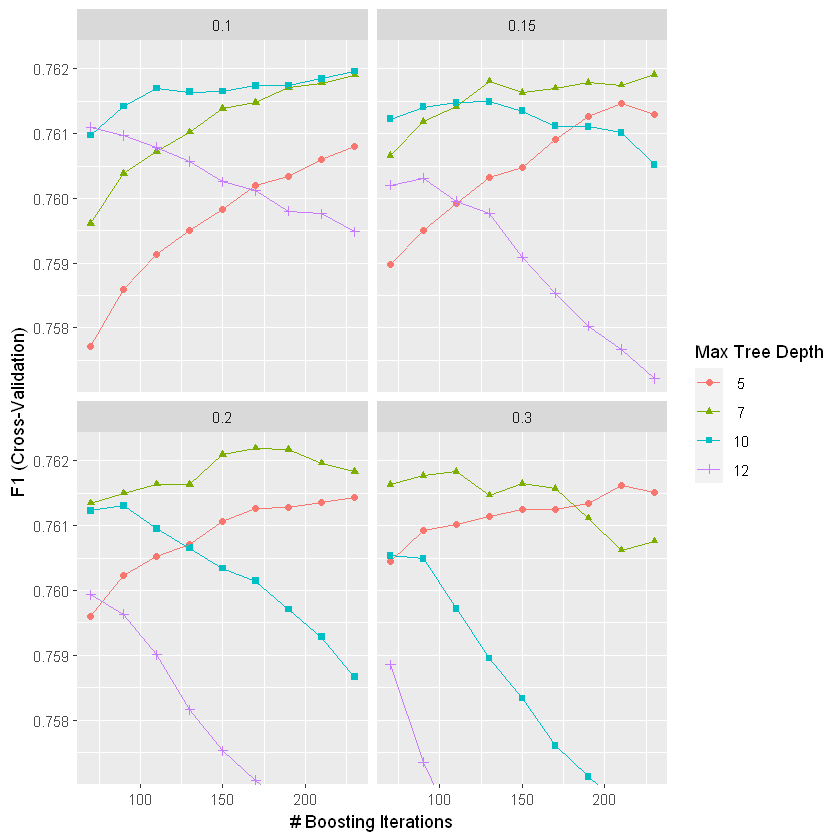


In [ ]:
max_depth_op <- xgb_model_1$bestTune$max_depth
eta_op <- xgb_model_1$bestTune$eta
nrounds_op <- xgb_model_1$bestTune$nrounds
rm('xgb_model_1')

In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (((nrounds_op/5)-4):((nrounds_op/5)+4))*5,
  max_depth = (max_depth_op - 1):(max_depth_op + 1),
  eta = eta_op,
  gamma = 0,
  colsample_bytree = 1,
  min_child_weight = c(1,2,4,8),
  subsample = 1
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_2 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_2$results
xgb_model_2$bestTune

In [ ]:
tuneplot(xgb_model_2)

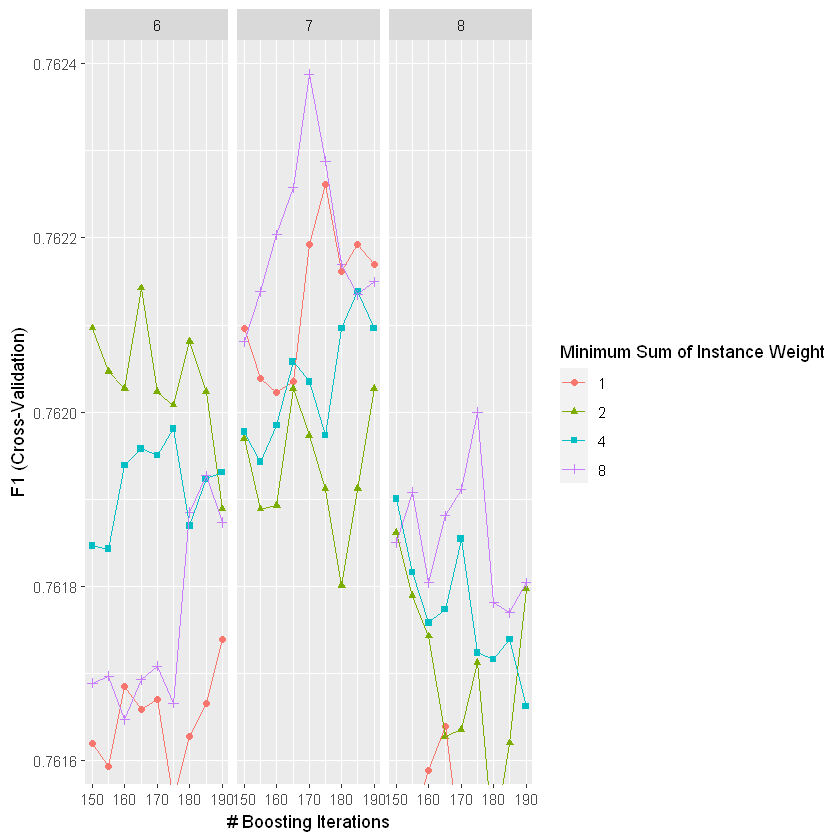


In [ ]:
max_depth_op <- xgb_model_2$bestTune$max_depth
min_child_weight_op <- xgb_model_2$bestTune$min_child_weight
nrounds_op <- xgb_model_2$bestTune$nrounds
rm('xgb_model_2')

In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (((nrounds_op/5)-2):((nrounds_op/5)+2))*5,
  max_depth = max_depth_op,
  eta = eta_op,
  gamma = 0,
  colsample_bytree = c(0.5,0.7,0.9,1),
  min_child_weight = min_child_weight_op,
  subsample = c(0.5,0.7,0.9,1)
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_3 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_3$results
xgb_model_3$bestTune

In [ ]:
tuneplot(xgb_model_3)

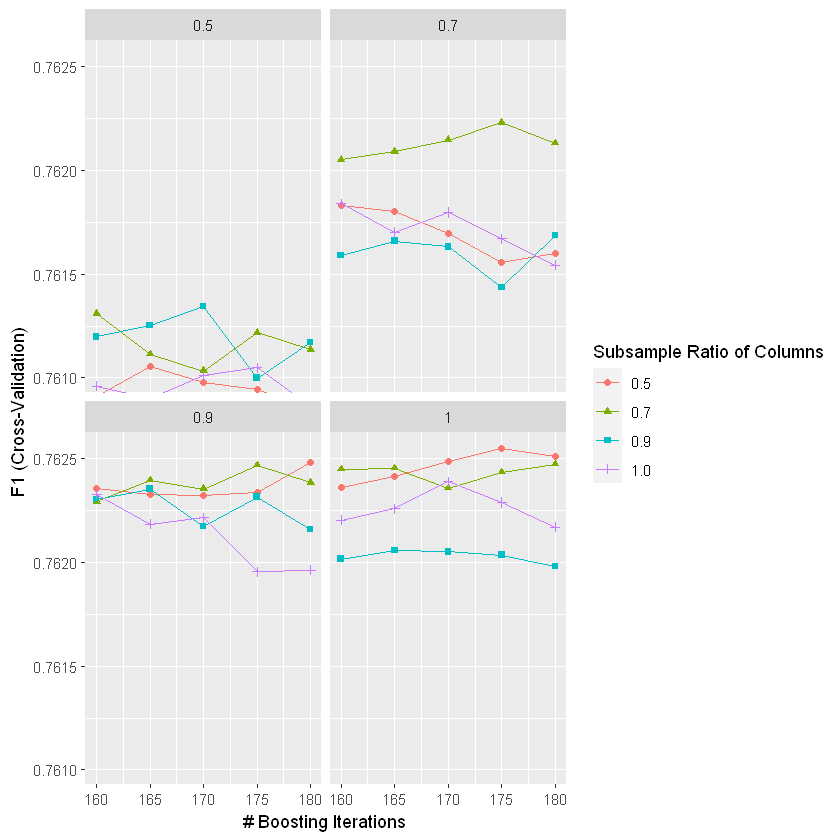


In [ ]:
colsample_bytree_op <- xgb_model_3$bestTune$colsample_bytree 
subsample_op <- xgb_model_3$bestTune$subsample
nrounds_op <- xgb_model_3$bestTune$nrounds
rm('xgb_model_3')

In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = (((nrounds_op/5)-2):((nrounds_op/5)+2))*5,
  max_depth = max_depth_op,
  eta = eta_op,
  gamma = c(0, 0.05, 0.1, 0.5, 0.7, 0.9, 1.0),
  colsample_bytree = colsample_bytree_op,
  min_child_weight = min_child_weight_op,
  subsample = subsample_op
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_4 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_4$results
xgb_model_4$bestTune

In [ ]:
tuneplot(xgb_model_4)

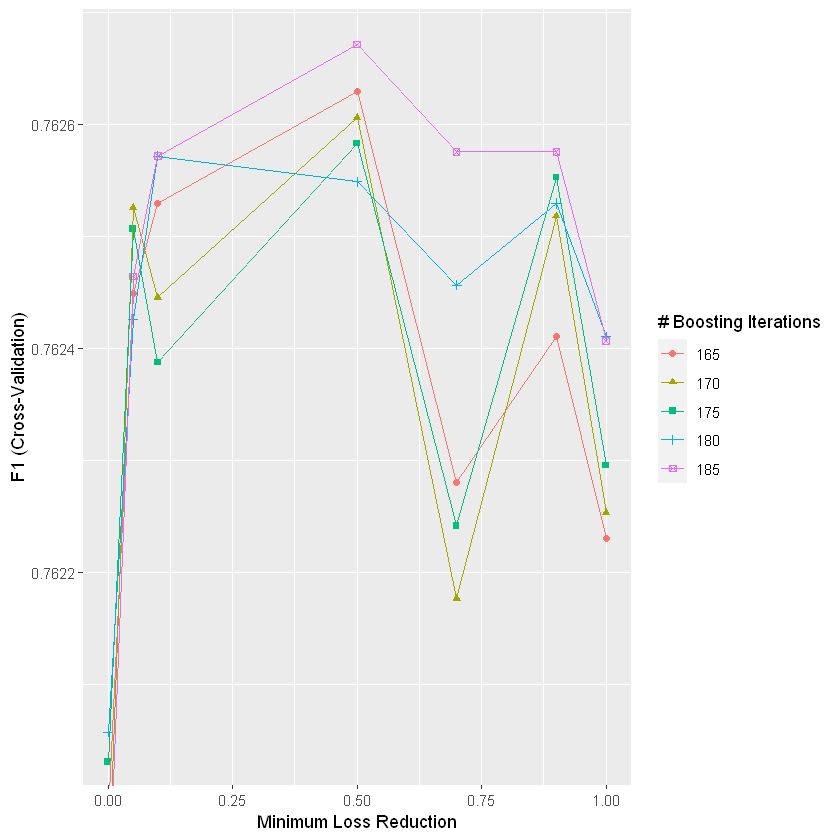


In [ ]:
gamma_op <- xgb_model_4$bestTune$gamma
nrounds_op <- xgb_model_4$bestTune$nrounds
rm('xgb_model_4')

In [ ]:
# Here are the values obtained after tuning 
nrounds_op <- 185
max_depth_op <- 7
eta_op <- 0.2
gamma_op <- 0.5
colsample_bytree_op <- 0.5
min_child_weight_op <- 8
subsample_op <-1

We can already see the f1 score of our model with the chosen parameters in the table above, to have an idea of how long our model will run. 

And this way we can compare it with the ones that we remove the parameters from the feature selection 


In [ ]:
set.seed(2)

tic()
grid_default <- expand.grid(
  nrounds = nrounds_op,
  max_depth = max_depth_op,
  eta = eta_op,
  gamma = gamma_op,
  colsample_bytree = colsample_bytree_op,
  min_child_weight = min_child_weight_op,
  subsample = subsample_op
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_op <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_op$results

In [ ]:
# We can now make this cell run 
X <- X[,ranking.xgb[-c(13,14,21,22,45,46,51,52)]]
#data.xgb <- data.xgb[,setdiff(colnames(data.xgb),colnames(data.xgb[,ranking.xgb[c(13,14,21,22,45,46,51,52)]]))]
#test.xgb <- test.xgb[,setdiff(colnames(test.xgb),colnames(test.xgb[,ranking.xgb[c(13,14,21,22,45,46,51,52)]]))]


In [ ]:
set.seed(2) 

tic()
grid_default <- expand.grid(
  nrounds = nrounds_op,
  max_depth = max_depth_op,
  eta = eta_op,
  gamma = gamma_op,
  colsample_bytree = colsample_bytree_op,
  min_child_weight = min_child_weight_op,
  subsample = subsample_op
)

train_control <- caret::trainControl(
    method = "cv",
    number = 5,
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction =  f1
)

xgb_model_op_1 <- caret::train(
    x = X,
    y = as.factor(y),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = FALSE,
    metric = "F1"
)
toc()
xgb_model_op_1$results

As opposed to what we could expected, removing features did not make our computation time lower, but it did induce a slight decrease of the F1 score.

# 4. Submission of our prediction to DrivenData



We had the best score on DrivenData with a randomForest algorithm. 

In [ ]:
datam<-read.csv("data_target_encoding.csv",stringsAsFactors = T)
test<-read.csv("test_target_encoding.csv",stringsAsFactors = T)

In [ ]:
set.seed(2)
n_trees <- 500
nfeat <- ncol(datam)-1 #I remove 1 to remove damage_grade
m_tries <- c(floor(0.5*sqrt(nfeat)))
nrows<-nrow(datam)
target_variable <- match('damage_grade', colnames(datam))

model <- randomForest(x=datam[,-c(target_variable)],
                    y=as.factor(datam[,c(target_variable)]),
                    ntree=n_trees,mtry=m_tries,keep.forest=TRUE,importance=TRUE)
yhat<-predict(model,test[,-c(target_variable)])
submission<-read.csv("submission_format.csv",stringsAsFactors = T)
submission[,2]<-as.integer(yhat)
write.csv(submission,'submission_test_RF_500.csv',col.names=TRUE,row.names=FALSE)

Our best try was actually with 1000 trees, but the computational cost of this try was not worth the negligible increase in accuracy (we went up from 0.7461 to 0.7462)

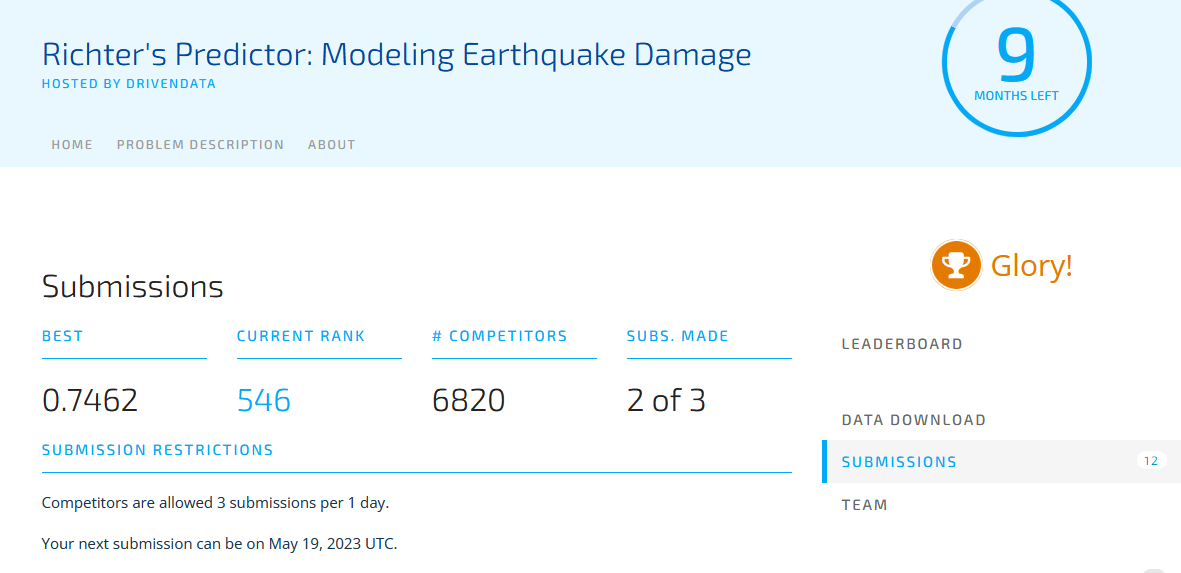

# 5. Ranking of the features in terms of relevance by the conditional entropy



In [ ]:
train_values <- read.csv("train_values.csv",stringsAsFactors = T)
test_values <- read.csv("test_values.csv",stringsAsFactors = T)
train_labels <- read.csv("train_labels.csv",stringsAsFactors = T)

There are 38 basic relevant variables. For the calculation of the entropy, we will use our linear model. Let's take a look at our 38 base variables and what is left after applying our pre-processing and feature selection strategy for the linear model.

In [ ]:
# The 38 relevant features are as follows
feature_initial <- colnames(test_values[,-1])
feature_initial

[1] "geo_level_1_id"                        
 [2] "geo_level_2_id"                        
 [3] "geo_level_3_id"                        
 [4] "count_floors_pre_eq"                   
 [5] "age"                                   
 [6] "area_percentage"                       
 [7] "height_percentage"                     
 [8] "land_surface_condition"                
 [9] "foundation_type"                       
[10] "roof_type"                             
[11] "ground_floor_type"                     
[12] "other_floor_type"                      
[13] "position"                              
[14] "plan_configuration"                    
[15] "has_superstructure_adobe_mud"          
[16] "has_superstructure_mud_mortar_stone"   
[17] "has_superstructure_stone_flag"         
[18] "has_superstructure_cement_mortar_stone"
[19] "has_superstructure_mud_mortar_brick"   
[20] "has_superstructure_cement_mortar_brick"
[21] "has_superstructure_timber"             
[22] "has_superstructure_bamboo"             
[23] "has_superstructure_rc_non_engineered"  
[24] "has_superstructure_rc_engineered"      
[25] "has_superstructure_other"              
[26] "legal_ownership_status"                
[27] "count_families"                        
[28] "has_secondary_use"                     
[29] "has_secondary_use_agriculture"         
[30] "has_secondary_use_hotel"               
[31] "has_secondary_use_rental"              
[32] "has_secondary_use_institution"         
[33] "has_secondary_use_school"              
[34] "has_secondary_use_industry"            
[35] "has_secondary_use_health_post"         
[36] "has_secondary_use_gov_office"          
[37] "has_secondary_use_use_police"          
[38] "has_secondary_use_other"

In [ ]:
length(feature_initial)

In [ ]:
# We apply our pre-processing and feature selection pipline for our linear model# 
dataNN <- read.csv("data_target_encoding_NN.csv",stringsAsFactors = T)
testNN <- read.csv("test_target_encoding_NN.csv",stringsAsFactors = T)
dataNN.lin <- dataNN[,-c(34,37,42,45,50,54,58,68)]
testNN.lin <- testNN[,-c(34,37,42,45,50,54,58,68)]
dataNN.lin <- dataNN.lin[,-c(13,14,19,20,21,24,25,26,27,28,29,30,31,32,35,44,46,51,52,53,54,55,56,57,58,59,60,61,62)]
testNN.lin <- testNN.lin[,-c(13,14,19,20,21,24,25,26,27,28,29,30,31,32,35,44,46,51,52,53,54,55,56,57,58,59,60,61,62)]
dataNN.lin <- dataNN.lin[,-c(12,24,28,15,31,10,32)]
testNN.lin <- testNN.lin[,-c(12,24,28,15,31,10,32)]

In [ ]:
# Along the way, we replaced some variables with others, via target encoding or dummy encoding and deleted some of its variables. 
# At the end of this process the remaining variables are as follows :
feature_final <- colnames(testNN.lin)
feature_final

In [ ]:
length(feature_final)

We will now give a ranking of the importance of the remaining variables via $H(y|X^{-i}) - H(y|X) = 0.$ Where, H(y|X) denotes the entropy of our predictor to which we have made the feature X eat. 

We start by computing the entropy of $H(y|X)$. To do this we start by training our model on the 18 features, as done previously. To make a prediction on the testing set. 

In [ ]:
X.train <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
X.test <- as.matrix(testNN.lin)
y.train <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)
beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
y.test <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat
pred.lin <- 1:nrow(y.test)
for (i in pred.lin){ pred.lin[i] <- which.max(y.test[i,])}

In [ ]:
df <- as.data.frame(pred.lin)
colnames(df) <- c('damage_grade')

df <- df %>% group_by(damage_grade) %>% 
  summarise('H' =n (),
            .groups = 'drop')

for (i in 1:3){df$H[i] <- df$H[i]/86868}
df

damage_grade,H
<int>,<dbl>
1,0.02957361
2,0.63616061
3,0.33426578


We calculate the entropy via the formula : $$H(y|X) = - \sum_y p(y) log(p(y)) $$

In [ ]:
H <- - df$H[1]*log(df$H[1]) - df$H[2]*log(df$H[2]) - df$H[3]*log(df$H[3])
H

[1] 0.7581578

We now proceed to the calculation of entropy $H(y|X^{-i})$. We have previously constructed a dataframe to compute the entropy, now we will do this iteratively to add the dataframes as columns, then we will compute each conditional entropy for the $X^{-i}$

In [ ]:
for (i in 1:26){
    dataNN.lin.copy <- dataNN.lin[,-i]
    testNN.lin.copy <- testNN.lin[,-i]
   
    X.train <- as.matrix(dataNN.lin.copy[,setdiff(colnames(dataNN.lin.copy),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    X.test <- as.matrix(testNN.lin.copy)
    y.train <- as.matrix(dataNN.lin.copy[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)
    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    y.test <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat
    pred.lin.copy <- 1:nrow(y.test)
    for (j in pred.lin.copy){ pred.lin.copy[j] <- which.max(y.test[j,])}
    
    ddf <- as.data.frame(pred.lin.copy)
    colnames(ddf) <- c('damage_grade')

    ddf <- ddf %>% group_by(damage_grade) %>% 
    summarise( 'A' = n(),
                .groups = 'drop')

    for (k in 1:3){ddf$A[k] <- ddf$A[k]/86868} #86868 is the nrow of the testing set

    df <- merge(df,ddf,by=c('damage_grade','damage_grade'),all.x=T)
    names(df)[i+2] = paste("H", i, sep = "") #allows to change the name of the columns
}
df

damage_grade,H,H1,H2,H3,H4,H5,H6,H7,H8,⋯,H17,H18,H19,H20,H21,H22,H23,H24,H25,H26
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.02957361,0.02953907,0.02950454,0.02949302,0.02993047,0.03033338,0.0299650,0.0296657,0.03073629,⋯,0.02953907,0.02226366,0.02283925,0.02635032,0.02869872,0.02957361,0.0287793,0.02895197,0.02964268,0.02963116
2,0.63616061,0.63757655,0.63631026,0.63789888,0.64069623,0.64554266,0.6521964,0.6362412,0.63499793,⋯,0.63620666,0.64168624,0.64164019,0.63870470,0.63673620,0.63627573,0.6364714,0.63719667,0.63636782,0.63614910
3,0.33426578,0.33288438,0.33418520,0.33260810,0.32937330,0.32412396,0.3178386,0.3340931,0.33426578,⋯,0.33425427,0.33605010,0.33552056,0.33494497,0.33456509,0.33415067,0.3347493,0.33385136,0.33398950,0.33421974


In [ ]:
entropie <- 0:26
for (i in entropie){ entropie[i+1] <-  -df[1,2+i]*log(df[1,2+i]) - df[2,2+i]*log(df[2,2+i]) - df[3,2+i]*log(df[3,2+i])}
entropie <- entropie - entropie[1] 
entropie <- entropie[2:27]
M <- matrix(0,26,2)
M[,1] <- entropie
M[,2] <- 1:26
M <- as.data.frame(M)
colnames(M) <- c('entropie','indice')
M <- M[order(M$entropie, decreasing = TRUE),]
M

,entropie,indice
,<dbl>,<dbl>
8,3.544150e-03,8
7,1.712837e-04,7
26,1.469314e-04,26
10,1.327375e-04,10
25,3.392743e-05,25
22,-7.410984e-05,22
17,-1.134035e-04,17
13,-2.150852e-04,13
16,-2.468669e-04,16


We finally obtain the ranking of the features in terms of the conditional entropy, computed with the linear model.

In [ ]:
colnames(dataNN.lin)[M$indice]

[1] "age"                                   
 [2] "count_floors_pre_eq"                   
 [3] "position_t"                            
 [4] "has_superstructure_adobe_mud"          
 [5] "other_floor_type_x"                    
 [6] "ground_floor_type_f"                   
 [7] "land_surface_condition_t"              
 [8] "has_superstructure_bamboo"             
 [9] "land_surface_condition_n"              
[10] "geo_level_1_sd_damage"                 
[11] "count_families"                        
[12] "area_percentage"                       
[13] "has_secondary_use_agriculture"         
[14] "has_superstructure_cement_mortar_brick"
[15] "geo_level_1_mean_damage"               
[16] "geo_level_2_mean_damage"               
[17] "geo_level_2_sd_damage"                 
[18] "ground_floor_type_v"                   
[19] "other_floor_type_j"                    
[20] "roof_type_x"                           
[21] "has_superstructure_mud_mortar_brick"   
[22] "geo_level_3_mean_damage"               
[23] "foundation_type_w"                     
[24] "geo_level_3_sd_damage"                 
[25] "foundation_type_u"                     
[26] "foundation_type_r"

# 6. Conclusion 

We have studied the performance of several algorithms on the multiclassification problem that is the evaluation of the damage grade on buildings during the 2015 Gurkha earthquake. 

Except the linear models, all of the models we used are known to be not very good at extrapolation. This could explain why we always got a F1 score that was around 0.02 lower on DrivenData than our own evaluations. 

The best performing model proved to be the random forest.